# CDS-Fusion-V2.2: Clinically-Motivated Dual-Stream Fusion Network### Fixed: Linearized Findings + Standard CE Classifier + Higher Encoder LR**v2.2 Fixes applied:**1. **Linearized findings** — converts `EF: 41%` → `Ejection fraction 41 percent` (BERT-friendly)2. **Replaced CORAL** with Focal CE + ordinal distance penalty (no threshold collapse)3. **Higher encoder LR** — `lr × 0.3` instead of `lr × 0.1` (encoders adapt faster)> ⚡ **Runtime → A100 GPU** selected

## 1. Setup

In [3]:
!pip install -q transformers scikit-learn pandas matplotlib seaborn xgboost

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## 2. Upload Data

In [4]:
from google.colab import files
import os, pandas as pd

if not os.path.exists("/content/Final_data.csv"):
    uploaded = files.upload()

df = pd.read_csv("/content/Final_data.csv")
print(f"Dataset: {len(df)} records")
print(f"Labels: {df['label'].value_counts().sort_index().to_dict()}")

Dataset: 718 records
Labels: {'Mild': 269, 'Moderate': 205, 'Normal': 165, 'Severe': 79}


## 3. Model File (v2.2 — all fixes applied)- `_linearize_findings()` converts key-value pairs → natural language- `ClassificationHead` replaces broken CORAL classifier- `CDSFusionV2Loss` uses Focal CE + ordinal distance + R-Drop

In [5]:
%%writefile cds_fusion_v2_model.py
"""
CDS-Fusion-V2: Clinically-Motivated Dual-Stream Fusion Network
================================================================
for Automated Severity Classification of Echocardiography Reports

KEY INSIGHT:
  Echocardiography reports have two semantically distinct components:

  1. CLINICAL FINDINGS — measurements (EF, LVIDd, LA...), structural
     descriptions (LV_Cavity_Size, Wall_Motion...), valve findings,
     flow patterns. These are OBJECTIVE observations.

  2. IMPRESSION — the cardiologist's DIAGNOSTIC CONCLUSION summarizing
     the findings. This is a SUBJECTIVE clinical judgment.

  A cardiologist reads findings → forms an impression → assigns severity.
  Our architecture mirrors this exact clinical reasoning process.

ARCHITECTURE:
  ┌─────────────────────────────────────────────────────────────────┐
  │                    CDS-Fusion-V2 Architecture                   │
  │                                                                 │
  │   Stream 1: Clinical Findings          Stream 2: Impression     │
  │   ─────────────────────────            ────────────────────     │
  │   "Age: 55, Sex: Male,                "MI (inferior) with      │
  │    EF: 41%, LVIDd: 56 mm,              moderate LV systolic    │
  │    LV_Cavity_Size: Dilated,            dysfunction."           │
  │    Wall_Motion: hypokinetic,                                   │
  │    VSD: Absent, ..."                                           │
  │         │                                     │                │
  │    ┌────▼─────┐                         ┌─────▼──────┐        │
  │    │ BioBERT  │                         │ClinicalBERT│        │
  │    │ + LoRA   │                         │  + LoRA    │        │
  │    └────┬─────┘                         └─────┬──────┘        │
  │         │                                     │                │
  │    ┌────▼─────┐                         ┌─────▼──────┐        │
  │    │Findings  │                         │Impression  │        │
  │    │  CDA     │◄───── Cross-Doc ───────►│   CDA      │        │
  │    └────┬─────┘       Attention         └─────┬──────┘        │
  │         │                                     │                │
  │         └──────────┐     ┌────────────────────┘                │
  │                    ▼     ▼                                     │
  │              ┌─────────────────┐                               │
  │              │  Gated Fusion   │                               │
  │              │  g⊙F + (1-g)⊙I │                               │
  │              └────────┬────────┘                               │
  │                       │                                        │
  │              ┌────────▼────────┐                               │
  │              │   HCFA (3-group │                               │
  │              │   hierarchical) │                               │
  │              └────────┬────────┘                               │
  │                       │                                        │
  │              ┌────────▼────────┐                               │
  │              │  CORAL + Focal  │                               │
  │              │  Classifier     │                               │
  │              └────────┬────────┘                               │
  │                       │                                        │
  │              Normal / Mild / Moderate / Severe                  │
  └─────────────────────────────────────────────────────────────────┘

WHY THIS SPLIT MATTERS:
  1. PREVENTS MEMORIZATION: 99.6% of impressions map to exactly one label.
     If the model sees the impression, it just memorizes the mapping.
     By separating streams, the findings stream MUST learn clinical reasoning.

  2. MAKES AUGMENTATION MEANINGFUL: Augmentation only modifies findings
     (measurement noise, synonym replacement). Since the findings stream
     has no access to impression, these changes actually matter.

  3. CROSS-DOCUMENT ATTENTION learns which findings support which impressions:
     "EF: 41% + Wall_Motion: hypokinetic" → "moderate LV dysfunction"
     This is clinically interpretable and publishable.

  4. MIRRORS CLINICAL PRACTICE: Cardiologists first read measurements,
     then structural findings, then form an impression. Our architecture
     does the same thing — scientifically and clinically motivated.

DATA:
  Input file: Final_data.csv (718 records)
  Splitting: Medical_Report is split at "Impression:" into two streams
  Labels: Normal (165), Mild (269), Moderate (205), Severe (79)

AUGMENTATION (Applied ONLY to Stream 1):
  - Measurement noise: ±3mm LVIDd/LVIDs, ±2mm LA/AO (Lang et al., 2015)
  - EF perturbation: ±5% within observed class range (Thavendiranathan 2013)
  - Severity-neutral synonym replacement: "Intact"→"no defect seen" only
  - Non-informative field masking: 9 constant fields only (Cramér V=0.000)
  - Two-stage: uniform augmentation (all classes) + minority oversampling

Author: [Your Name]
Affiliation: Kennesaw State University / InComm Healthcare
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import math
import re
import random
import numpy as np
import pandas as pd
from typing import Optional, Tuple, Dict, List
from collections import Counter


# ============================================================================
# 1. DATA PREPARATION — Split Reports into Two Streams
# ============================================================================

class DualStreamEchoDataset(Dataset):
    """
    Dataset that splits each echocardiography report into two streams:

    Stream 1 (findings_text): All clinical fields EXCEPT Impression
      → "Age: 55, Sex: Male, EF: 41%, LVIDd: 56 mm, ..., Others_Flow: Nill"
      → Fed to BioBERT
      → This is the "clinical evidence" that the model must reason over
      → AUGMENTATION is applied here

    Stream 2 (impression_text): Only the Impression field
      → "Consistent with MI with moderate LV systolic dysfunction."
      → Fed to ClinicalBERT
      → This is the "diagnostic reference" signal
      → NEVER augmented (modifying impression = modifying the diagnosis)

    This split forces the model to learn:
    "WHICH findings → WHICH impression → WHICH severity"
    instead of shortcutting through impression memorization.
    """

    def __init__(
        self,
        texts: List[str],
        labels: List[int],
        bio_tokenizer: AutoTokenizer,
        clin_tokenizer: AutoTokenizer,
        max_findings_len: int = 256,
        max_impression_len: int = 64,
        linearize: bool = True,
    ):
        self.labels = labels
        self.bio_tokenizer = bio_tokenizer
        self.clin_tokenizer = clin_tokenizer
        self.max_findings_len = max_findings_len
        self.max_impression_len = max_impression_len

        # Split each report into findings and impression
        self.findings_texts = []
        self.impression_texts = []

        for text in texts:
            findings, impression = self._split_report(text)
            # FIX v2.2: Linearize key-value pairs into natural language
            if linearize:
                findings = self._linearize_findings(findings)
            self.findings_texts.append(findings)
            self.impression_texts.append(impression)

    @staticmethod
    def _split_report(text: str) -> Tuple[str, str]:
        """
        Split a medical report text at the Impression field.

        Input:  "Age: 55, Sex: Male, ..., Others_Flow: Nill, Impression: MI with..."
        Output: ("Age: 55, Sex: Male, ..., Others_Flow: Nill",
                 "MI with moderate LV systolic dysfunction.")
        """
        parts = text.rsplit('Impression:', 1)
        findings = parts[0].strip().rstrip(',').strip()
        impression = parts[1].strip() if len(parts) > 1 else ""

        # If impression is empty, use a placeholder
        if not impression or impression.lower() in ['nan', 'n/a', 'nill', '']:
            impression = "No impression documented."

        return findings, impression

    @staticmethod
    def _linearize_findings(findings_text: str) -> str:
        """
        FIX v2.2: Convert structured key-value findings into natural language.

        BERT was pretrained on sentences, not "EF: 41%, LVIDd: 56 mm".
        Linearization converts structured data into BERT-friendly text.

        Before: "Age: 55, Sex: Male, EF: 41%, LVIDd: 56 mm, LV_Cavity_Size: Dilated"
        After:  "Patient age 55 years, male. Ejection fraction 41 percent.
                 LV internal dimension diastole 56 millimeters. LV cavity size dilated."
        """
        # Field-to-natural-language mapping
        FIELD_MAP = {
            'Age': ('Patient age', 'years'),
            'Sex': ('Sex', ''),
            'IVST': ('Interventricular septal thickness', 'millimeters'),
            'LVIDd': ('LV internal dimension in diastole', 'millimeters'),
            'LA': ('Left atrium', 'millimeters'),
            'LVPWT': ('LV posterior wall thickness', 'millimeters'),
            'LVIDs': ('LV internal dimension in systole', 'millimeters'),
            'AO': ('Aortic root', 'millimeters'),
            'RVGWT': ('RV free wall thickness', 'millimeters'),
            'FS': ('Fractional shortening', 'percent'),
            'ACS': ('Aortic cusp separation', 'millimeters'),
            'RV': ('Right ventricle', 'millimeters'),
            'EF': ('Ejection fraction', 'percent'),
            'LVEDV': ('LV end diastolic volume', 'milliliters'),
            'PA': ('Pulmonary artery', 'millimeters'),
            'EF_Shope': ('EF by Shope method', 'percent'),
            'LVESV': ('LV end systolic volume', 'milliliters'),
            'AV_ring': ('Aortic valve ring', 'millimeters'),
            'MV_ring': ('Mitral valve ring', 'millimeters'),
            'MVA': ('Mitral valve area', 'square centimeters'),
            'LV_Cavity_Size': ('LV cavity size is', ''),
            'LV_Wall_Thickness': ('LV wall thickness is', ''),
            'LV_Wall_Motion': ('LV wall motion shows', ''),
            'RA': ('Right atrium is', ''),
            'MV': ('Mitral valve is', ''),
            'RV_Description': ('Right ventricle is', ''),
            'AV': ('Aortic valve is', ''),
            'LA_Description': ('Left atrium is', ''),
            'PV': ('Pulmonary valve is', ''),
            'Aorta': ('Aorta is', ''),
            'TV': ('Tricuspid valve is', ''),
            'PA_Description': ('Pulmonary artery is', ''),
            'IAS': ('Interatrial septum is', ''),
            'RVOT': ('RV outflow tract is', ''),
            'IVS': ('Interventricular septum is', ''),
            'ASD': ('Atrial septal defect is', ''),
            'Thrombus': ('Thrombus is', ''),
            'VSD': ('Ventricular septal defect is', ''),
            'Vegetation': ('Vegetation is', ''),
            'PDA': ('Patent ductus arteriosus is', ''),
            'Pericardium': ('Pericardium is', ''),
            'Mitral_Valve_Flow': ('Mitral valve flow shows', ''),
            'Aortic_Valve_Flow': ('Aortic valve flow shows', ''),
            'Pulmonary_Valve_Flow': ('Pulmonary valve flow shows', ''),
            'Tricuspid_Valve_Flow': ('Tricuspid valve flow shows', ''),
            'VSD_Flow': ('VSD flow shows', ''),
            'Others_Flow': ('Other flow findings', ''),
        }

        sentences = []
        # Parse key-value pairs
        for field in findings_text.split(','):
            field = field.strip()
            if ':' not in field:
                continue
            key, val = field.split(':', 1)
            key = key.strip()
            val = val.strip()

            # Skip nan/empty values
            if val.lower() in ['nan', 'n/a', '', 'not measured', 'not reported']:
                continue

            if key in FIELD_MAP:
                label, unit = FIELD_MAP[key]
                # Extract numeric value if present
                num_match = re.match(r'(\d+\.?\d*)\s*(%|mm|sqcm)?', val)
                if num_match and unit:
                    num_val = num_match.group(1)
                    sentences.append(f"{label} {num_val} {unit}.")
                else:
                    # Categorical/text value
                    val_clean = val.rstrip('.').strip()
                    sentences.append(f"{label} {val_clean.lower()}.")
            else:
                # Unknown field — keep as is
                sentences.append(f"{key} {val}.")

        return ' '.join(sentences) if sentences else findings_text

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Tokenize findings for BioBERT (Stream 1)
        findings_enc = self.bio_tokenizer(
            self.findings_texts[idx],
            max_length=self.max_findings_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Tokenize impression for ClinicalBERT (Stream 2)
        impression_enc = self.clin_tokenizer(
            self.impression_texts[idx],
            max_length=self.max_impression_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'bio_input_ids': findings_enc['input_ids'].squeeze(0),
            'bio_attention_mask': findings_enc['attention_mask'].squeeze(0),
            'clin_input_ids': impression_enc['input_ids'].squeeze(0),
            'clin_attention_mask': impression_enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


def prepare_data(csv_path: str) -> Tuple[List[str], List[int], Dict[int, str]]:
    """
    Load Final_data.csv and prepare for training.

    Returns:
        texts: List of full Medical_Report strings
        labels: List of integer labels
        label_map_inv: {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}
    """
    df = pd.read_csv(csv_path)

    label_map = {'Normal': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
    label_map_inv = {v: k for k, v in label_map.items()}

    texts = df['Medical_Report'].tolist()
    labels = [label_map[l] for l in df['label'].tolist()]

    print(f"Loaded {len(texts)} records from {csv_path}")
    print(f"Label distribution: {dict(Counter(labels))}")

    return texts, labels, label_map_inv


# ============================================================================
# 2. AUGMENTATION — Applied ONLY to Stream 1 (Clinical Findings)
# ============================================================================

class FindingsAugmenter:
    """
    Clinically-validated augmentation for echocardiographic FINDINGS only.

    THIS IS THE KEY DESIGN DECISION:
    - Augmentation modifies ONLY the findings text (Stream 1)
    - Impression (Stream 2) is NEVER modified
    - Because findings and impression are in SEPARATE streams, the model
      cannot shortcut through the impression to ignore augmented findings
    - Therefore, augmentation actually affects what the model learns!

    Without this split, augmentation was WASTED because:
    - Impression (7% of text, Cramér's V=1.000) was unchanged
    - Model learned to just read Impression and ignore everything else
    - Changing "EF: 41%" → "EF: 43%" had zero effect on model behavior

    With this split, augmentation is MEANINGFUL because:
    - Stream 1 has NO impression — model must learn from findings
    - Changing "EF: 41%" → "EF: 43%" directly affects Stream 1 representation
    - Model must learn: which EF values → which severity levels

    All augmentations cite published literature:
    - Measurement noise: Lang et al. (2015) inter-observer variability
    - EF perturbation: Thavendiranathan et al. (2013) reproducibility
    - Field masking: Validated by Cramér's V analysis (9 constant fields)
    """

    # Data-driven EF distributions per class (from actual dataset analysis)
    EF_DISTRIBUTIONS = {
        'Normal':   {'mean': 59.7, 'std': 7.2,  'min': 45, 'max': 75},
        'Mild':     {'mean': 55.9, 'std': 8.3,  'min': 42, 'max': 71},
        'Moderate': {'mean': 48.9, 'std': 11.8, 'min': 26, 'max': 77},
        'Severe':   {'mean': 43.9, 'std': 16.8, 'min': 25, 'max': 89},
    }

    # Measurement noise bounds (published inter-observer variability)
    MEASUREMENT_NOISE = {
        'LVIDd': 3,   # ±3mm (Lang 2015)
        'LVIDs': 3,   # ±3mm
        'LA': 2,      # ±2mm
        'AO': 2,      # ±2mm
        'IVST': 2,    # ±2mm
        'LVPWT': 2,   # ±2mm
    }

    # ONLY severity-neutral synonyms (Cramér's V = 0.000 for these terms)
    SAFE_SYNONYMS = {
        'Intact': ['no defect seen'],
        'Absent': ['not detected', 'not seen'],
        'Nill': ['none'],
        'Normal flow.': ['Normal flow pattern.'],
        'Normal Flow.': ['Normal flow pattern.'],
    }

    # NEVER replace these — they are severity discriminative
    FORBIDDEN_TERMS = {
        'normal', 'hypokinetic', 'akinetic', 'dilated', 'thickened',
        'regurgitation', 'stenosis', 'dyskinetic', 'poor', 'good',
        'mild', 'moderate', 'severe', 'trivial', 'significant',
    }

    # Fields safe to mask (100% constant across all classes, Cramér V=0.000)
    SAFE_TO_MASK_FIELDS = [
        'RVGWT', 'FS', 'PA', 'EF_Shope', 'LVEDV', 'LVESV',
        'AV_ring', 'MV_ring', 'RVOT'
    ]

    # NEVER mask these (severity-discriminative, Cramér V > 0.15)
    NEVER_MASK_FIELDS = [
        'EF', 'LVIDd', 'LVIDs', 'LA', 'AO', 'IVST', 'LVPWT', 'Age', 'Sex',
        'LV_Cavity_Size', 'LV_Wall_Thickness', 'LV_Wall_Motion',
        'VSD', 'ASD', 'PDA', 'ACS', 'RV', 'IAS', 'IVS',
        'Mitral_Valve_Flow', 'Aortic_Valve_Flow', 'Tricuspid_Valve_Flow',
        'Pulmonary_Valve_Flow', 'VSD_Flow', 'Others_Flow',
        'RA', 'MV', 'AV', 'LA_Description', 'Aorta', 'TV', 'PV',
        'RV_Description', 'PA_Description', 'Thrombus', 'Vegetation',
        'Pericardium', 'MVA',
    ]

    def __init__(self, severity_label: str, augment_prob: float = 0.4):
        self.severity_label = severity_label
        self.augment_prob = augment_prob

    def augment_findings(self, findings_text: str) -> str:
        """
        Apply all augmentation strategies to findings text.
        NOTE: This is called ONLY on Stream 1 text (no Impression).
        """
        text = findings_text

        if random.random() < self.augment_prob:
            text = self._ef_perturbation(text)

        if random.random() < self.augment_prob:
            text = self._measurement_noise(text)

        if random.random() < self.augment_prob:
            text = self._synonym_replacement(text, max_replacements=2)

        if random.random() < self.augment_prob:
            text = self._field_masking(text, max_masks=2)

        return text

    def _ef_perturbation(self, text: str) -> str:
        """Add ±5% Gaussian noise to EF within observed class range."""
        dist = self.EF_DISTRIBUTIONS.get(self.severity_label)
        if not dist:
            return text

        def perturb_ef(match):
            original_ef = float(match.group(1))
            noise = random.gauss(0, 5)  # ±5% inter-observer variability
            new_ef = int(round(original_ef + noise))
            new_ef = max(dist['min'], min(dist['max'], new_ef))
            return f"EF: {new_ef}%"

        return re.sub(r'EF:\s*(\d+)%', perturb_ef, text)

    def _measurement_noise(self, text: str) -> str:
        """Add inter-observer measurement variability noise."""
        for field, max_noise in self.MEASUREMENT_NOISE.items():
            pattern = rf'{field}:\s*(\d+)\s*mm'
            match = re.search(pattern, text)
            if match:
                original = int(match.group(1))
                noise = random.uniform(-max_noise, max_noise)
                new_val = max(1, int(round(original + noise)))
                text = re.sub(pattern, f'{field}: {new_val} mm', text)
        return text

    def _synonym_replacement(self, text: str, max_replacements: int = 2) -> str:
        """Replace ONLY severity-neutral terms."""
        replaced = 0
        for original, synonyms in self.SAFE_SYNONYMS.items():
            if replaced >= max_replacements:
                break
            if original in text:
                synonym = random.choice(synonyms)
                text = text.replace(original, synonym, 1)
                replaced += 1
        return text

    def _field_masking(self, text: str, max_masks: int = 2) -> str:
        """Mask only non-informative constant fields."""
        masked = 0
        fields_to_mask = random.sample(
            self.SAFE_TO_MASK_FIELDS,
            min(max_masks, len(self.SAFE_TO_MASK_FIELDS))
        )
        for field in fields_to_mask:
            pattern = rf'{field}:\s*[^,]+'
            if re.search(pattern, text):
                text = re.sub(pattern, f'{field}: not reported', text)
                masked += 1
        return text


def augment_dataset_two_stage(
    texts: List[str],
    labels: List[int],
    label_map_inv: Dict[int, str],
) -> Tuple[List[str], List[int]]:
    """
    Two-stage augmentation (uniform + oversampling).

    Stage 1: Apply augmentation uniformly to ALL classes (prevents
             asymmetric augmentation artifact bias)
    Stage 2: Oversample minority classes by duplicating from the
             augmented pool

    IMPORTANT: Augmentation modifies only the FINDINGS portion.
    The Impression is never touched. When the augmented text is later
    split by DualStreamEchoDataset._split_report(), the Impression
    remains identical to the original.
    """
    counts = Counter(labels)

    # Stage 1: Uniform augmentation (one variant per sample, all classes)
    stage1_texts = list(texts)
    stage1_labels = list(labels)

    for idx in range(len(texts)):
        original = texts[idx]
        label_id = labels[idx]
        severity_name = label_map_inv[label_id]

        # Split → augment findings only → rejoin
        findings, impression = DualStreamEchoDataset._split_report(original)
        augmenter = FindingsAugmenter(severity_label=severity_name, augment_prob=0.4)
        aug_findings = augmenter.augment_findings(findings)

        # Rejoin into full text (impression stays identical)
        aug_text = f"{aug_findings}, Impression: {impression}"

        stage1_texts.append(aug_text)
        stage1_labels.append(label_id)

    # Stage 2: Minority oversampling to balance classes
    stage2_target = max(Counter(stage1_labels).values())
    final_texts = list(stage1_texts)
    final_labels = list(stage1_labels)

    for label_id, count in Counter(stage1_labels).items():
        if count >= stage2_target:
            continue
        indices = [i for i, l in enumerate(stage1_labels) if l == label_id]
        needed = stage2_target - count
        for _ in range(needed):
            idx = random.choice(indices)
            final_texts.append(stage1_texts[idx])
            final_labels.append(label_id)

    print(f"\nAugmentation summary:")
    print(f"  Original: {dict(counts)}")
    print(f"  After Stage 1 (uniform): {dict(Counter(stage1_labels))}")
    print(f"  After Stage 2 (balanced): {dict(Counter(final_labels))}")
    print(f"  Total: {len(texts)} → {len(final_texts)}")

    return final_texts, final_labels


# ============================================================================
# 3. ENCODER FINE-TUNING (Selective Layer Unfreezing + Optional PEFT LoRA)
# ============================================================================
#
# CRITICAL FIX (v2.1): The original LoRA implementation applied LoRA deltas
# POST-HOC to the final hidden state, not INSIDE the attention layers.
# This meant the attention computation used un-adapted Q,V projections,
# making LoRA ineffective (F1 ≈ 0.29, near random).
#
# Two correct approaches:
#   Option A: PEFT library (pip install peft) — proper hook-based LoRA
#   Option B: Selective layer unfreezing — simpler, no extra dependency
#
# Default: Option B (unfreezing). Set use_peft_lora=True for Option A.

class LoRALinear(nn.Module):
    """
    LoRA-enhanced Linear layer that REPLACES the original linear.
    This ensures LoRA is applied INSIDE the computation, not post-hoc.

    Output = W_frozen(x) + scaling * B(A(dropout(x)))
    """
    def __init__(self, original_linear: nn.Linear, rank: int = 8,
                 alpha: float = 16.0, dropout: float = 0.05):
        super().__init__()
        self.original = original_linear
        self.original.weight.requires_grad = False
        if self.original.bias is not None:
            self.original.bias.requires_grad = False

        in_f = original_linear.in_features
        out_f = original_linear.out_features
        self.scaling = alpha / rank

        self.lora_A = nn.Linear(in_f, rank, bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        self.lora_dropout = nn.Dropout(dropout)

        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    @property
    def weight(self):
        return self.original.weight

    @property
    def bias(self):
        return self.original.bias

    @property
    def in_features(self):
        return self.original.in_features

    @property
    def out_features(self):
        return self.original.out_features

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Original frozen output + LoRA trainable delta
        base_out = self.original(x)
        lora_out = self.lora_B(self.lora_A(self.lora_dropout(x))) * self.scaling
        return base_out + lora_out


def setup_encoder(model: nn.Module, mode: str = "unfreeze",
                  num_unfreeze_layers: int = 4,
                  lora_rank: int = 8, lora_alpha: float = 16.0) -> int:
    """
    Configure encoder for training. Two modes:

    mode="unfreeze": Freeze layers 0-(N-k), unfreeze last k layers.
        Simple, reliable, well-proven for clinical NLP.
        ~25M trainable params per encoder (last 4 layers).

    mode="lora": Replace Q,V projections in last k layers with LoRALinear.
        Proper in-place LoRA (not the broken post-hoc version).
        ~50K trainable params per encoder.

    Returns: number of trainable parameters.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False

    trainable_params = 0
    num_layers = len(model.encoder.layer)
    target_start = max(0, num_layers - num_unfreeze_layers)

    if mode == "unfreeze":
        # Unfreeze last N layers + pooler
        for layer_idx in range(target_start, num_layers):
            for param in model.encoder.layer[layer_idx].parameters():
                param.requires_grad = True
                trainable_params += param.numel()

    elif mode == "lora":
        # Replace Q,V linear layers with LoRALinear in last N layers
        for layer_idx in range(target_start, num_layers):
            attention = model.encoder.layer[layer_idx].attention.self
            for proj_name in ["query", "value"]:
                original = getattr(attention, proj_name)
                lora_linear = LoRALinear(original, rank=lora_rank, alpha=lora_alpha)
                setattr(attention, proj_name, lora_linear)
                trainable_params += sum(
                    p.numel() for p in lora_linear.parameters() if p.requires_grad
                )

    return trainable_params


# ============================================================================
# 4. CLINICAL DOMAIN ATTENTION (CDA) — Per-Stream
# ============================================================================

class ClinicalDomainAttention(nn.Module):
    """
    CDA with multi-sample dropout regularization.

    For Stream 1 (findings): learns which measurements/findings matter most
    For Stream 2 (impression): learns which impression words are key

    The attention weights from both streams are INTERPRETABLE:
    - Stream 1 attention → "model focused on EF, Wall_Motion, VSD"
    - Stream 2 attention → "model focused on 'moderate', 'dysfunction'"
    """
    def __init__(self, hidden_size: int, dropout: float = 0.2,
                 num_dropout_samples: int = 5):
        super().__init__()
        self.num_dropout_samples = num_dropout_samples
        self.attention_mlp = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 1),
        )
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, hidden_states: torch.Tensor,
                attention_mask: Optional[torch.Tensor] = None
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        scores = self.attention_mlp(hidden_states).squeeze(-1)
        if attention_mask is not None:
            scores = scores.masked_fill(attention_mask == 0, float("-inf"))
        attention_weights = F.softmax(scores, dim=-1)

        attended = torch.bmm(attention_weights.unsqueeze(1), hidden_states).squeeze(1)

        if self.training and self.num_dropout_samples > 1:
            outputs = [self.dropout(attended) for _ in range(self.num_dropout_samples)]
            attended = torch.stack(outputs).mean(dim=0)
        else:
            attended = self.dropout(attended)

        return self.layer_norm(attended), attention_weights


# ============================================================================
# 5. CROSS-STREAM GATED FUSION MODULE (CSGFM)
# ============================================================================

class CrossStreamGatedFusion(nn.Module):
    """
    Learns a dynamic gate: how much to weight findings vs impression.

    g = sigmoid(W[findings; impression])
    fused = g ⊙ findings + (1-g) ⊙ impression

    The gate value g is INTERPRETABLE:
    - g → 1.0: model relies more on clinical findings
    - g → 0.0: model relies more on impression
    - Per-sample g values can be reported in the paper
    """
    def __init__(self, hidden_size: int, dropout: float = 0.2):
        super().__init__()
        bottleneck = hidden_size // 4
        self.gate_network = nn.Sequential(
            nn.Linear(hidden_size * 2, bottleneck),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(bottleneck, hidden_size),
            nn.Sigmoid(),
        )
        self.output_norm = nn.LayerNorm(hidden_size)
        self.output_dropout = nn.Dropout(dropout)

    def forward(self, findings_repr: torch.Tensor,
                impression_repr: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        gate_input = torch.cat([findings_repr, impression_repr], dim=-1)
        gate = self.gate_network(gate_input)
        fused = gate * findings_repr + (1 - gate) * impression_repr
        return self.output_dropout(self.output_norm(fused)), gate


# ============================================================================
# 6. HIERARCHICAL CLINICAL FEATURE AGGREGATOR (HCFA)
# ============================================================================

class LightweightHCFA(nn.Module):
    """
    3-group hierarchical aggregation matching clinical report structure:
      Group 1: Measurements (EF, dimensions — numeric clinical evidence)
      Group 2: Structural findings (wall motion, valve status — categorical)
      Group 3: Diagnostic summary (impression-derived features)

    Learned queries attend to the fused sequence to extract group-specific
    representations, then aggregate into a single feature vector.
    """
    def __init__(self, hidden_size: int, num_entity_groups: int = 3,
                 num_heads: int = 2, dropout: float = 0.2):
        super().__init__()
        self.group_queries = nn.Parameter(torch.randn(num_entity_groups, hidden_size))
        nn.init.xavier_uniform_(self.group_queries.unsqueeze(0))

        self.group_attention = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.aggregator = nn.Sequential(
            nn.Linear(hidden_size * num_entity_groups, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
        )

    def forward(self, sequence_hidden: torch.Tensor,
                attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        batch_size = sequence_hidden.size(0)
        queries = self.group_queries.unsqueeze(0).expand(batch_size, -1, -1)
        key_pad_mask = (attention_mask == 0) if attention_mask is not None else None

        group_repr, _ = self.group_attention(
            query=queries, key=sequence_hidden, value=sequence_hidden,
            key_padding_mask=key_pad_mask,
        )
        return self.aggregator(group_repr.reshape(batch_size, -1))


# ============================================================================
# 7. CLASSIFICATION HEAD (Standard CE + Ordinal Distance)
# ============================================================================

class ClassificationHead(nn.Module):
    """
    FIX v2.2: Replaced CORAL (caused threshold collapse → only 2 of 4 classes).

    Standard softmax classifier with:
    - Two-layer MLP bottleneck
    - Direct 4-class logits (no cumulative sigmoid thresholds)
    - Auxiliary ordinal head for ordinal distance penalty

    This is simpler, more robust, and doesn't suffer from threshold collapse.
    """
    def __init__(self, hidden_size: int, num_classes: int = 4, dropout: float = 0.3):
        super().__init__()
        self.num_classes = num_classes

        bottleneck = hidden_size // 4  # 192

        self.shared_ffn = nn.Sequential(
            nn.Linear(hidden_size, bottleneck),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # Primary: standard 4-class classification
        self.main_classifier = nn.Linear(bottleneck, num_classes)
        # Auxiliary: scalar severity score for ordinal penalty
        self.ordinal_head = nn.Linear(bottleneck, 1)

    def forward(self, features: torch.Tensor) -> Dict[str, torch.Tensor]:
        shared = self.shared_ffn(features)
        logits = self.main_classifier(shared)
        probs = F.softmax(logits, dim=-1)
        ordinal_score = self.ordinal_head(shared).squeeze(-1)

        return {
            "logits": logits,
            "probs": probs,
            "ordinal_score": ordinal_score,
        }


# ============================================================================
# 8. COMPLETE CDS-FUSION-V2 MODEL
# ============================================================================

class CDSFusionV2(nn.Module):
    """
    CDS-Fusion-V2: Clinically-Motivated Dual-Stream Fusion Network.

    Stream 1 (BioBERT + LoRA):  Clinical findings (measurements, structures, flows)
    Stream 2 (ClinicalBERT + LoRA): Impression text (diagnostic conclusion)

    Key difference from V1:
    - V1: Both streams received the SAME full report text
    - V2: Each stream receives DIFFERENT, clinically-motivated input
    - V1: Model shortcutted through Impression in both streams
    - V2: Stream 1 has NO impression — must learn from clinical evidence
    - V1: Augmentation was wasted (impression unchanged, model ignored rest)
    - V2: Augmentation is meaningful (Stream 1 directly affected)

    Trainable params: ~2M (LoRA + adapters + fusion + classifier)
    Frozen params: ~220M (both BERT encoders)
    """

    def __init__(
        self,
        biobert_name: str = "dmis-lab/biobert-base-cased-v1.2",
        clinicalbert_name: str = "emilyalsentzer/Bio_ClinicalBERT",
        num_classes: int = 4,
        lora_rank: int = 8,
        lora_alpha: float = 16.0,
        dropout: float = 0.25,
        num_dropout_samples: int = 5,
        encoder_mode: str = "unfreeze",  # "unfreeze" or "lora"
        num_unfreeze_layers: int = 4,
    ):
        super().__init__()
        self.num_classes = num_classes

        # ---- Load encoders ----
        self.biobert = AutoModel.from_pretrained(biobert_name)
        self.clinicalbert = AutoModel.from_pretrained(clinicalbert_name)
        hidden_size = self.biobert.config.hidden_size  # 768

        # ---- Configure encoder training ----
        # FIXED v2.1: Uses proper in-place LoRA or selective unfreezing
        # instead of broken post-hoc LoRA that caused F1≈0.29
        bio_trainable = setup_encoder(
            self.biobert, mode=encoder_mode,
            num_unfreeze_layers=num_unfreeze_layers,
            lora_rank=lora_rank, lora_alpha=lora_alpha,
        )
        clin_trainable = setup_encoder(
            self.clinicalbert, mode=encoder_mode,
            num_unfreeze_layers=num_unfreeze_layers,
            lora_rank=lora_rank, lora_alpha=lora_alpha,
        )

        # ---- Lightweight adapter projections ----
        self.findings_adapter = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size),
            nn.LayerNorm(hidden_size),
        )
        self.impression_adapter = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size),
            nn.LayerNorm(hidden_size),
        )

        # ---- Per-stream CDA ----
        self.findings_cda = ClinicalDomainAttention(hidden_size, dropout, num_dropout_samples)
        self.impression_cda = ClinicalDomainAttention(hidden_size, dropout, num_dropout_samples)

        # ---- Cross-Stream Gated Fusion ----
        self.fusion = CrossStreamGatedFusion(hidden_size, dropout)

        # ---- Sequence-level fusion for HCFA ----
        self.seq_fusion_proj = nn.Linear(hidden_size * 2, hidden_size)
        self.hcfa = LightweightHCFA(hidden_size, num_entity_groups=3, num_heads=2, dropout=dropout)

        # ---- Feature combination ----
        self.feature_combiner = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
        )

        # ---- Standard classifier (replaced CORAL) ----
        self.classifier = ClassificationHead(hidden_size, num_classes, dropout=0.3)

        # ---- Parameter summary ----
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n{'='*60}")
        print(f"CDS-Fusion-V2.1 Model Summary (FIXED)")
        print(f"{'='*60}")
        print(f"Encoder mode:         {encoder_mode}")
        print(f"Stream 1: BioBERT  → Clinical Findings (augmentable)")
        print(f"Stream 2: ClinicalBERT → Impression (not augmented)")
        print(f"{'='*60}")
        print(f"Total parameters:     {total:>12,d}")
        print(f"Trainable parameters: {trainable:>12,d} ({trainable/total*100:.1f}%)")
        print(f"Frozen parameters:    {total-trainable:>12,d} ({(total-trainable)/total*100:.1f}%)")
        print(f"BioBERT trainable:    {bio_trainable:>12,d}")
        print(f"ClinicalBERT train:   {clin_trainable:>12,d}")
        print(f"{'='*60}\n")

    def _encode(self, model: nn.Module, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        """
        FIXED: Simple forward pass through encoder.

        With 'unfreeze' mode: last N layers have requires_grad=True,
        so gradients flow through them normally during backprop.

        With 'lora' mode: Q,V projections are LoRALinear modules that
        compute W_frozen(x) + B(A(x)) IN-PLACE during the attention
        computation. No post-hoc modification needed.

        Both modes work correctly with a standard forward call.
        """
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

    def forward(
        self,
        bio_input_ids: torch.Tensor,       # Stream 1: findings tokens
        bio_attention_mask: torch.Tensor,
        clin_input_ids: torch.Tensor,       # Stream 2: impression tokens
        clin_attention_mask: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        """
        Forward pass:
        1. Encode findings with BioBERT (unfrozen/LoRA layers adapt representations)
        2. Encode impression with ClinicalBERT (same)
        3. Per-stream CDA (extract key representations)
        4. Gated fusion (learn findings-vs-impression weighting)
        5. HCFA (hierarchical feature aggregation)
        6. Ordinal classification
        """
        # ---- Stream 1: Clinical Findings (BioBERT) ----
        findings_seq = self._encode(self.biobert, bio_input_ids, bio_attention_mask)
        findings_seq = self.findings_adapter(findings_seq)
        findings_pooled, findings_attn = self.findings_cda(findings_seq, bio_attention_mask)

        # ---- Stream 2: Impression (ClinicalBERT) ----
        impression_seq = self._encode(self.clinicalbert, clin_input_ids, clin_attention_mask)
        impression_seq = self.impression_adapter(impression_seq)
        impression_pooled, impression_attn = self.impression_cda(impression_seq, clin_attention_mask)

        # ---- Gated Fusion ----
        fused_pooled, gate_values = self.fusion(findings_pooled, impression_pooled)

        # ---- Sequence-Level Fusion for HCFA ----
        min_len = min(findings_seq.size(1), impression_seq.size(1))
        seq_concat = torch.cat([
            findings_seq[:, :min_len, :],
            impression_seq[:, :min_len, :]
        ], dim=-1)
        seq_fused = self.seq_fusion_proj(seq_concat)

        mask_trunc = bio_attention_mask[:, :min_len]
        hcfa_repr = self.hcfa(seq_fused, mask_trunc)

        # ---- Combine & Classify ----
        combined = torch.cat([fused_pooled, hcfa_repr], dim=-1)
        features = self.feature_combiner(combined)

        outputs = self.classifier(features)

        # Store attention weights and gate values for interpretability
        outputs["findings_attention"] = findings_attn
        outputs["impression_attention"] = impression_attn
        outputs["gate_values"] = gate_values

        return outputs


# ============================================================================
# 9. LOSS FUNCTION (Focal CE + Ordinal Distance + R-Drop)
# ============================================================================

class CDSFusionV2Loss(nn.Module):
    """
    FIX v2.2: Replaced CORAL loss (threshold collapse) with:

    1. Focal Cross-Entropy (primary): Handles class imbalance
       - Standard CE with focal modulation: (1-pt)^γ * CE
       - Class weights for Severe (79 samples) vs Mild (269 samples)

    2. Ordinal Distance Penalty (auxiliary): Preserves ordinality
       - MSE between predicted severity score and true ordinal label
       - Captures: Normal(0) < Mild(1) < Moderate(2) < Severe(3)
       - Simpler than CORAL, doesn't suffer threshold collapse

    3. R-Drop KL Divergence: Regularization for low-resource
       - Dual forward pass with different dropout masks
       - Minimizes KL divergence between two outputs
    """
    def __init__(self, num_classes: int = 4, focal_weight: float = 0.6,
                 ordinal_weight: float = 0.2, rdrop_weight: float = 0.2,
                 focal_gamma: float = 2.0, label_smoothing: float = 0.1,
                 class_weights: Optional[torch.Tensor] = None,
                 # Keep old param names for backward compat (ignored)
                 coral_weight: float = 0.0, focal_w_old: float = 0.0):
        super().__init__()
        self.num_classes = num_classes
        self.focal_w = focal_weight
        self.ordinal_w = ordinal_weight
        self.rdrop_w = rdrop_weight
        self.focal_gamma = focal_gamma
        self.label_smoothing = label_smoothing
        if class_weights is not None:
            self.register_buffer("class_weights", class_weights)
        else:
            self.class_weights = None

    def focal_loss(self, logits, labels):
        """Focal Cross-Entropy: down-weights easy examples, focuses on hard ones."""
        ce = F.cross_entropy(logits, labels, weight=self.class_weights,
                             label_smoothing=self.label_smoothing, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.focal_gamma) * ce).mean()

    def ordinal_distance_loss(self, ordinal_scores, labels):
        """
        MSE between predicted severity score and true ordinal position.
        Forces the model to learn: Normal=0 < Mild=1 < Moderate=2 < Severe=3.
        """
        targets = labels.float()
        return F.mse_loss(ordinal_scores, targets)

    def rdrop_kl(self, logits1, logits2):
        """Symmetric KL divergence between two forward passes."""
        p = F.log_softmax(logits1, -1)
        q = F.log_softmax(logits2, -1)
        return (F.kl_div(p, F.softmax(logits2, -1), reduction="batchmean") +
                F.kl_div(q, F.softmax(logits1, -1), reduction="batchmean")) / 2

    def forward(self, out1, out2, labels):
        focal = self.focal_loss(out1["logits"], labels)
        ordinal = self.ordinal_distance_loss(out1["ordinal_score"], labels)
        total = self.focal_w * focal + self.ordinal_w * ordinal

        rdrop = torch.tensor(0.0, device=labels.device)
        if out2 is not None and self.training:
            focal2 = self.focal_loss(out2["logits"], labels)
            ordinal2 = self.ordinal_distance_loss(out2["ordinal_score"], labels)
            total = (total + self.focal_w * focal2 + self.ordinal_w * ordinal2) / 2
            rdrop = self.rdrop_kl(out1["logits"], out2["logits"])
            total += self.rdrop_w * rdrop

        return {"total_loss": total, "focal_loss": focal,
                "ordinal_loss": ordinal, "rdrop_loss": rdrop}


# ============================================================================
# 10. TRAINING UTILITIES
# ============================================================================

def compute_class_weights(labels: List[int], num_classes: int = 4) -> torch.Tensor:
    """Inverse frequency class weights for imbalanced data."""
    counts = Counter(labels)
    total = len(labels)
    weights = torch.tensor([total / (num_classes * counts[i]) for i in range(num_classes)])
    return weights / weights.sum() * num_classes


def get_predictions(outputs: Dict[str, torch.Tensor]) -> torch.Tensor:
    """Get predicted class from softmax probabilities."""
    return outputs["probs"].argmax(dim=-1)


# ============================================================================
# 11. MAIN — Example Usage
# ============================================================================

if __name__ == "__main__":

    # ---- Configuration ----
    CONFIG = {
        "data_path": "Final_data.csv",
        "biobert_name": "dmis-lab/biobert-base-cased-v1.2",
        "clinicalbert_name": "emilyalsentzer/Bio_ClinicalBERT",
        "max_findings_len": 256,
        "max_impression_len": 64,
        "batch_size": 16,
        "learning_rate": 2e-4,
        "num_epochs": 30,
        "lora_rank": 8,
        "lora_alpha": 16.0,
        "dropout": 0.25,
        "num_folds": 5,
        "num_repeats": 3,  # Repeated Stratified K-Fold
        "swa_start_epoch": 20,
        "seed": 42,
    }

    print("=" * 60)
    print("CDS-Fusion-V2: Training Pipeline")
    print("=" * 60)

    # ---- Load Data ----
    texts, labels, label_map_inv = prepare_data(CONFIG["data_path"])

    # ---- Augment (findings only) ----
    aug_texts, aug_labels = augment_dataset_two_stage(texts, labels, label_map_inv)

    # ---- Tokenizers ----
    bio_tokenizer = AutoTokenizer.from_pretrained(CONFIG["biobert_name"])
    clin_tokenizer = AutoTokenizer.from_pretrained(CONFIG["clinicalbert_name"])

    # ---- Dataset ----
    dataset = DualStreamEchoDataset(
        aug_texts, aug_labels,
        bio_tokenizer, clin_tokenizer,
        max_findings_len=CONFIG["max_findings_len"],
        max_impression_len=CONFIG["max_impression_len"],
    )

    print(f"\nDataset created: {len(dataset)} samples")
    print(f"  Stream 1 (findings): max {CONFIG['max_findings_len']} tokens")
    print(f"  Stream 2 (impression): max {CONFIG['max_impression_len']} tokens")

    # ---- Model ----
    model = CDSFusionV2(
        biobert_name=CONFIG["biobert_name"],
        clinicalbert_name=CONFIG["clinicalbert_name"],
        lora_rank=CONFIG["lora_rank"],
        lora_alpha=CONFIG["lora_alpha"],
        dropout=CONFIG["dropout"],
    )

    # ---- Class weights ----
    weights = compute_class_weights(aug_labels)
    print(f"Class weights: {weights.tolist()}")

    # ---- Loss ----
    criterion = CDSFusionV2Loss(class_weights=weights)

    # ---- Training would continue with:
    # - RepeatedStratifiedKFold (5-fold × 3 repeats)
    # - AdamW optimizer with cosine annealing
    # - SWA from epoch 20
    # - R-Drop (two forward passes per batch)
    # - Bootstrapped confidence intervals
    # - McNemar's test against baselines

    print("\n✅ Model ready for training!")
    print("Next steps: implement training loop with RepeatedStratifiedKFold")


Writing cds_fusion_v2_model.py


In [6]:
import importlib, cds_fusion_v2_model
importlib.reload(cds_fusion_v2_model)
from cds_fusion_v2_model import DualStreamEchoDataset

# Test linearization
sample = "Age: 55, Sex: Male, EF: 41%, LVIDd: 56 mm, LV_Cavity_Size: Dilated, LV_Wall_Motion: hypokinetic, Impression: Moderate dysfunction."
f, i = DualStreamEchoDataset._split_report(sample)
f_lin = DualStreamEchoDataset._linearize_findings(f)
print(f"✅ Model loaded")
print(f"\nRaw findings:        {f}")
print(f"Linearized findings: {f_lin}")
print(f"Impression:          {i}")

✅ Model loaded

Raw findings:        Age: 55, Sex: Male, EF: 41%, LVIDd: 56 mm, LV_Cavity_Size: Dilated, LV_Wall_Motion: hypokinetic
Linearized findings: Patient age 55 years. Sex male. Ejection fraction 41 percent. LV internal dimension in diastole 56 millimeters. LV cavity size is dilated. LV wall motion shows hypokinetic.
Impression:          Moderate dysfunction.


## 4. Training File (v2.2)

In [19]:
%%writefile train_cds_fusion_v2.py
"""
Training Pipeline for CDS-Fusion-V2
=============================================
Clinically-Motivated Dual-Stream Fusion Network

Complete pipeline:
  1. Data loading and preprocessing
  2. Two-stage augmentation (findings-only)
  3. Repeated Stratified K-Fold (3×5)
  4. R-Drop training with gradient accumulation
  5. Stochastic Weight Averaging (SWA)
  6. Comprehensive evaluation with CI
  7. Visualization and results export
  8. Interpretability (gate analysis, attention extraction)

Usage:
  python train_cds_fusion_v2.py

  Or with custom config:
  python train_cds_fusion_v2.py --data_path /path/to/Final_data.csv --epochs 40

Author: [Your Name]
Affiliation: Kennesaw State University / InComm Healthcare
"""

import os
import re
import json
import copy
import random
import logging
import warnings
import argparse
from datetime import datetime
from pathlib import Path
from collections import Counter
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    cohen_kappa_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer

from cds_fusion_v2_model import (
    CDSFusionV2,
    CDSFusionV2Loss,
    DualStreamEchoDataset,
    FindingsAugmenter,
    augment_dataset_two_stage,
    prepare_data,
    compute_class_weights,
    get_predictions,
    setup_encoder,
    LoRALinear,
)

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

class V2Config:
    """Training configuration optimized for 718 samples with dual-stream split."""

    # ---- Data ----
    data_path: str = "/content/Final_data.csv"
    label_col: str = "label"
    text_col: str = "Medical_Report"
    label_map: Dict[str, int] = {
        "Normal": 0, "Mild": 1, "Moderate": 2, "Severe": 3,
    }
    num_classes: int = 4

    # ---- Model ----
    biobert_name: str = "dmis-lab/biobert-base-cased-v1.2"
    clinicalbert_name: str = "emilyalsentzer/Bio_ClinicalBERT"
    max_findings_len: int = 256    # ~189 max tokens observed, 256 gives margin
    max_impression_len: int = 64   # ~58 max tokens observed, 64 gives margin
    lora_rank: int = 8
    lora_alpha: float = 16.0
    dropout: float = 0.25
    num_dropout_samples: int = 5
    encoder_mode: str = "unfreeze"  # "unfreeze" (recommended) or "lora"
    num_unfreeze_layers: int = 4    # Unfreeze last 4 BERT layers per encoder

    # ---- Training ----
    num_folds: int = 5
    num_repeats: int = 3           # 3×5 = 15 evaluations for stable CI
    epochs: int = 40
    batch_size: int = 8
    gradient_accumulation_steps: int = 4   # effective batch = 32
    learning_rate: float = 3e-4
    weight_decay: float = 0.05
    max_grad_norm: float = 1.0
    early_stopping_patience: int = 10
    swa_start_epoch: int = 25

    # ---- Loss ----
    focal_weight: float = 0.6        # Primary: Focal CE for class imbalance
    ordinal_weight: float = 0.2      # Auxiliary: ordinal distance penalty
    rdrop_weight: float = 0.2
    focal_gamma: float = 2.0
    label_smoothing: float = 0.1     # Reduced from 0.15 (was too aggressive)
    severe_boost: float = 1.5        # Extra weight for Severe class
    encoder_lr_factor: float = 0.3   # FIX v2.2: encoder_lr = lr × 0.3 (was 0.1, too low)

    # ---- Augmentation ----
    augment_train: bool = True
    on_the_fly_augment: bool = True   # Additional per-epoch augmentation

    # ---- Misc ----
    seed: int = 42
    output_dir: str = "outputs_v2"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    # FIXED: AMP only on GPU. On CPU it causes numerical instability
    use_amp: bool = torch.cuda.is_available()
    num_workers: int = 0 if not torch.cuda.is_available() else 2  # 0 on CPU avoids multiprocessing overhead

    def to_dict(self) -> dict:
        return {k: v for k, v in self.__class__.__dict__.items()
                if not k.startswith('_') and not callable(v)}


def set_seed(seed: int):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================================
# 2. TEXT PREPROCESSING
# ============================================================================

def preprocess_report(text: str) -> str:
    """
    Light cleaning of raw Medical_Report text before splitting.
    Note: Unit conversion (mm→millimeters, %→percent) is now handled
    by _linearize_findings(), so we only do whitespace and nan cleanup here.
    """
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ============================================================================
# 3. ON-THE-FLY AUGMENTED DATASET
# ============================================================================

class OnTheFlyDualStreamDataset(DualStreamEchoDataset):
    """
    Extends DualStreamEchoDataset with on-the-fly augmentation.

    During training, each __getitem__ call randomly augments the FINDINGS
    portion of the text with a different augmentation each epoch.
    This creates implicit data expansion without storing augmented copies.

    The IMPRESSION portion is NEVER augmented.

    FIX v2.2: Augmentation happens on RAW findings (key-value pairs),
    then linearization converts to natural language for BERT.
    """

    def __init__(
        self,
        texts: List[str],
        labels: List[int],
        bio_tokenizer: AutoTokenizer,
        clin_tokenizer: AutoTokenizer,
        label_map_inv: Dict[int, str],
        max_findings_len: int = 256,
        max_impression_len: int = 64,
        augment: bool = False,
        augment_prob: float = 0.4,
        linearize: bool = True,
    ):
        # Don't call parent __init__ — we handle splitting differently
        self.labels = labels
        self.bio_tokenizer = bio_tokenizer
        self.clin_tokenizer = clin_tokenizer
        self.max_findings_len = max_findings_len
        self.max_impression_len = max_impression_len
        self.augment = augment
        self.label_map_inv = label_map_inv
        self.linearize = linearize

        # Store RAW findings (key-value format) for augmentation
        # and impressions separately
        self.raw_findings = []
        self.impression_texts = []
        for text in texts:
            findings, impression = self._split_report(text)
            self.raw_findings.append(findings)
            self.impression_texts.append(impression)

        # Pre-linearize for validation (no augmentation)
        if not augment:
            self.findings_texts = []
            for f in self.raw_findings:
                self.findings_texts.append(
                    self._linearize_findings(f) if linearize else f
                )

        # Per-class augmenters
        self.augmenters = {}
        for label_id, label_name in label_map_inv.items():
            self.augmenters[label_id] = FindingsAugmenter(
                severity_label=label_name, augment_prob=augment_prob
            )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        impression = self.impression_texts[idx]
        label = self.labels[idx]

        if self.augment:
            # Augment RAW findings first (key-value format)
            raw = self.raw_findings[idx]
            if label in self.augmenters:
                raw = self.augmenters[label].augment_findings(raw)
            # Then linearize the augmented findings
            findings = self._linearize_findings(raw) if self.linearize else raw
        else:
            findings = self.findings_texts[idx]

        # Tokenize
        findings_enc = self.bio_tokenizer(
            findings,
            max_length=self.max_findings_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        impression_enc = self.clin_tokenizer(
            impression,
            max_length=self.max_impression_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'bio_input_ids': findings_enc['input_ids'].squeeze(0),
            'bio_attention_mask': findings_enc['attention_mask'].squeeze(0),
            'clin_input_ids': impression_enc['input_ids'].squeeze(0),
            'clin_attention_mask': impression_enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long),
        }


# ============================================================================
# 4. WEIGHTED SAMPLER FOR IMBALANCED DATA
# ============================================================================

def get_weighted_sampler(labels: List[int]) -> WeightedRandomSampler:
    """Inverse-frequency weighted sampler for class-balanced batches."""
    counts = Counter(labels)
    class_weights = {k: 1.0 / v for k, v in counts.items()}
    sample_weights = [class_weights[l] for l in labels]
    return WeightedRandomSampler(
        weights=sample_weights, num_samples=len(labels), replacement=True,
    )


# ============================================================================
# 5. TRAINING LOOP (R-Drop: dual forward pass)
# ============================================================================

def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: CDSFusionV2Loss,
    optimizer: torch.optim.Optimizer,
    scheduler: Optional[object],
    scaler: GradScaler,
    config: V2Config,
    epoch: int,
) -> Dict[str, float]:
    """
    Train one epoch with R-Drop regularization.

    R-Drop runs TWO forward passes with different dropout masks per batch
    and minimizes the KL divergence between outputs. This acts as a strong
    regularizer, especially effective for small datasets (Liang et al., 2021).
    """
    model.train()
    total_loss = 0.0
    total_focal = 0.0
    total_ordinal = 0.0
    total_rdrop = 0.0
    num_batches = 0

    optimizer.zero_grad()

    for step, batch in enumerate(dataloader):
        bio_ids = batch["bio_input_ids"].to(config.device)
        bio_mask = batch["bio_attention_mask"].to(config.device)
        clin_ids = batch["clin_input_ids"].to(config.device)
        clin_mask = batch["clin_attention_mask"].to(config.device)
        labels = batch["labels"].to(config.device)

        with autocast(enabled=config.use_amp):
            # Forward pass 1
            outputs1 = model(bio_ids, bio_mask, clin_ids, clin_mask)
            # Forward pass 2 (different dropout masks → R-Drop)
            outputs2 = model(bio_ids, bio_mask, clin_ids, clin_mask)

            losses = criterion(outputs1, outputs2, labels)
            loss = losses["total_loss"] / config.gradient_accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % config.gradient_accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()

        total_loss += losses["total_loss"].item()
        total_focal += losses["focal_loss"].item()
        total_ordinal += losses["ordinal_loss"].item()
        total_rdrop += losses["rdrop_loss"].item()
        num_batches += 1

    return {
        "train_loss": total_loss / max(num_batches, 1),
        "focal_loss": total_focal / max(num_batches, 1),
        "ordinal_loss": total_ordinal / max(num_batches, 1),
        "rdrop_loss": total_rdrop / max(num_batches, 1),
    }


# ============================================================================
# 6. EVALUATION
# ============================================================================

@torch.no_grad()
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: CDSFusionV2Loss,
    config: V2Config,
) -> Dict:
    """
    Evaluate with full metrics including gate value analysis.

    Returns comprehensive metrics + interpretability data:
    - Standard: accuracy, F1, QWK, MAE
    - Interpretability: per-class gate values (findings vs impression reliance)
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_gate_values = []
    total_loss = 0.0
    num_batches = 0

    for batch in dataloader:
        bio_ids = batch["bio_input_ids"].to(config.device)
        bio_mask = batch["bio_attention_mask"].to(config.device)
        clin_ids = batch["clin_input_ids"].to(config.device)
        clin_mask = batch["clin_attention_mask"].to(config.device)
        labels = batch["labels"].to(config.device)

        with autocast(enabled=config.use_amp):
            outputs = model(bio_ids, bio_mask, clin_ids, clin_mask)
            losses = criterion(outputs, None, labels)

        total_loss += losses["total_loss"].item()
        num_batches += 1

        probs = outputs["probs"]
        preds = probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        # Collect gate values for interpretability
        if "gate_values" in outputs:
            gate = outputs["gate_values"].mean(dim=-1)  # Average across hidden dim
            all_gate_values.extend(gate.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    inv_map = {v: k for k, v in config.label_map.items()}
    target_names = [inv_map[i] for i in range(config.num_classes)]

    # ROC-AUC (one-vs-rest)
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    # Gate analysis: per-class average gate value
    gate_analysis = {}
    if all_gate_values:
        gate_arr = np.array(all_gate_values)
        for cls_id, cls_name in inv_map.items():
            mask = all_labels == cls_id
            if mask.sum() > 0:
                gate_analysis[cls_name] = {
                    "mean_gate": float(gate_arr[mask].mean()),
                    "std_gate": float(gate_arr[mask].std()),
                }

    return {
        "val_loss": total_loss / max(num_batches, 1),
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro"),
        "f1_weighted": f1_score(all_labels, all_preds, average="weighted"),
        "qwk": cohen_kappa_score(all_labels, all_preds, weights="quadratic"),
        "mae": float(np.mean(np.abs(all_preds - all_labels))),
        "roc_auc": roc_auc,
        "classification_report": classification_report(
            all_labels, all_preds, target_names=target_names,
            digits=4, output_dict=True, zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(all_labels, all_preds),
        "gate_analysis": gate_analysis,
        "all_preds": all_preds,
        "all_labels": all_labels,
        "all_probs": all_probs,
    }


# ============================================================================
# 7. STOCHASTIC WEIGHT AVERAGING (SWA)
# ============================================================================

class SWAModel:
    """
    Running average of model weights across late epochs.
    Leads to wider optima → better generalization on small datasets.
    """
    def __init__(self, model: nn.Module):
        self.swa_state = copy.deepcopy(model.state_dict())
        self.num_averaged = 0

    def update(self, model: nn.Module):
        state = model.state_dict()
        self.num_averaged += 1
        for key in self.swa_state:
            if state[key].is_floating_point():
                self.swa_state[key] = (
                    self.swa_state[key] * (self.num_averaged - 1) + state[key]
                ) / self.num_averaged

    def apply(self, model: nn.Module):
        model.load_state_dict(self.swa_state)


# ============================================================================
# 8. VISUALIZATION
# ============================================================================

def plot_results(fold_metrics: List[Dict], config: V2Config, output_dir: str):
    """Comprehensive visualization of training results."""

    fig = plt.figure(figsize=(22, 14))
    fig.patch.set_facecolor('#0f1419')
    gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.35)

    inv_map = {v: k for k, v in config.label_map.items()}
    class_names = [inv_map[i] for i in range(config.num_classes)]
    colors = ['#4ade80', '#fbbf24', '#fb923c', '#f87171']

    def style_ax(ax, title):
        ax.set_facecolor('#0f1419')
        ax.set_title(title, color='#e2e8f0', fontsize=11, fontweight='bold', pad=10)
        ax.tick_params(colors='#94a3b8', labelsize=8)
        for spine in ax.spines.values():
            spine.set_color('#2a3555')

    # 1. F1 Macro across folds
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1, 'F1 Macro Across Folds')
    f1s = [m["f1_macro"] for m in fold_metrics]
    ax1.bar(range(1, len(f1s)+1), f1s, color='#3b82f6', alpha=0.8, edgecolor='#1a2238')
    ax1.axhline(y=np.mean(f1s), color='#22d3ee', linestyle='--',
                label=f'Mean: {np.mean(f1s):.3f}±{np.std(f1s):.3f}')
    ax1.fill_between(range(0, len(f1s)+2), np.mean(f1s)-np.std(f1s),
                     np.mean(f1s)+np.std(f1s), alpha=0.15, color='#22d3ee')
    ax1.set_xlabel('Fold', color='#94a3b8')
    ax1.set_ylabel('F1 Macro', color='#94a3b8')
    ax1.legend(facecolor='#1a2238', edgecolor='#2a3555', labelcolor='#e2e8f0', fontsize=8)
    ax1.set_ylim(0, 1)

    # 2. Aggregate confusion matrix
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2, 'Aggregate Confusion Matrix')
    total_cm = sum(m["confusion_matrix"] for m in fold_metrics)
    cm_norm = total_cm.astype(float) / total_cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names, ax=ax2,
                annot_kws={'size': 9, 'fontweight': 'bold'}, cbar_kws={'label': '%'})
    ax2.set_xlabel('Predicted', color='#94a3b8')
    ax2.set_ylabel('True', color='#94a3b8')

    # 3. Per-class F1 boxplot
    ax3 = fig.add_subplot(gs[0, 2])
    style_ax(ax3, 'Per-Class F1 Distribution')
    per_class_f1 = {cn: [] for cn in class_names}
    for m in fold_metrics:
        report = m["classification_report"]
        for cn in class_names:
            if cn in report:
                per_class_f1[cn].append(report[cn]["f1-score"])
    bp = ax3.boxplot([per_class_f1[cn] for cn in class_names],
                     labels=class_names, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color + '40')
        patch.set_edgecolor(color)
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('#94a3b8')
    ax3.set_ylabel('F1 Score', color='#94a3b8')
    ax3.set_ylim(0, 1)

    # 4. Gate analysis (NEW — V2 specific)
    ax4 = fig.add_subplot(gs[0, 3])
    style_ax(ax4, 'Gate Values (Findings vs Impression)')
    gate_means = {cn: [] for cn in class_names}
    for m in fold_metrics:
        ga = m.get("gate_analysis", {})
        for cn in class_names:
            if cn in ga:
                gate_means[cn].append(ga[cn]["mean_gate"])
    if any(gate_means.values()):
        positions = range(len(class_names))
        means = [np.mean(gate_means[cn]) if gate_means[cn] else 0 for cn in class_names]
        stds = [np.std(gate_means[cn]) if gate_means[cn] else 0 for cn in class_names]
        bars = ax4.bar(positions, means, yerr=stds, color=colors, alpha=0.8,
                       edgecolor='#1a2238', capsize=4, error_kw={'color': '#94a3b8'})
        ax4.set_xticks(positions)
        ax4.set_xticklabels(class_names, color='#94a3b8')
        ax4.set_ylabel('Mean Gate Value', color='#94a3b8')
        ax4.axhline(y=0.5, color='#94a3b8', linestyle=':', alpha=0.5)
        ax4.text(0.02, 0.95, 'g→1: relies on findings\ng→0: relies on impression',
                transform=ax4.transAxes, color='#64748b', fontsize=7, va='top')
        ax4.set_ylim(0, 1)

    # 5. Metrics summary
    ax5 = fig.add_subplot(gs[1, 0])
    style_ax(ax5, 'Aggregate Metrics (Mean ± Std)')
    metrics_keys = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'qwk', 'roc_auc']
    metric_labels = ['Accuracy', 'Bal. Acc', 'F1 Macro', 'F1 Wt', 'QWK', 'ROC-AUC']
    means = [np.mean([m[k] for m in fold_metrics]) for k in metrics_keys]
    stds = [np.std([m[k] for m in fold_metrics]) for k in metrics_keys]
    bars = ax5.barh(metric_labels, means, xerr=stds, color='#3b82f6', alpha=0.8,
                    edgecolor='#1a2238', capsize=3, error_kw={'color': '#94a3b8'})
    for bar, mean, std in zip(bars, means, stds):
        ax5.text(mean + std + 0.02, bar.get_y() + bar.get_height()/2,
                f'{mean:.3f}±{std:.3f}', va='center', color='#e2e8f0', fontsize=8)
    ax5.set_xlim(0, 1.2)

    # 6. MAE distribution
    ax6 = fig.add_subplot(gs[1, 1])
    style_ax(ax6, 'Mean Absolute Error (Ordinal)')
    maes = [m["mae"] for m in fold_metrics]
    ax6.bar(range(1, len(maes)+1), maes, color='#ef4444', alpha=0.7, edgecolor='#1a2238')
    ax6.axhline(y=np.mean(maes), color='#fbbf24', linestyle='--',
               label=f'Mean: {np.mean(maes):.3f}')
    ax6.set_xlabel('Fold', color='#94a3b8')
    ax6.set_ylabel('MAE', color='#94a3b8')
    ax6.legend(facecolor='#1a2238', edgecolor='#2a3555', labelcolor='#e2e8f0', fontsize=8)

    # 7. Architecture diagram (text)
    ax7 = fig.add_subplot(gs[1, 2])
    style_ax(ax7, 'CASCADE Architecture')
    ax7.axis('off')
    arch_text = [
        ("Stream 1 (BioBERT)", "Clinical Findings", "#3b82f6"),
        ("  ↓ LoRA adapters", "Last 4 layers", "#64748b"),
        ("  ↓ Findings CDA", "Attention pooling", "#64748b"),
        ("Stream 2 (ClinicalBERT)", "Impression Text", "#8b5cf6"),
        ("  ↓ LoRA adapters", "Last 4 layers", "#64748b"),
        ("  ↓ Impression CDA", "Attention pooling", "#64748b"),
        ("Cross-Stream Fusion", "Gated: g⊙F + (1-g)⊙I", "#06b6d4"),
        ("HCFA", "3-group hierarchical", "#f59e0b"),
        ("CORAL + Focal", "Ordinal classifier", "#ef4444"),
    ]
    for i, (name, desc, color) in enumerate(arch_text):
        y = 0.95 - i * 0.105
        ax7.text(0.05, y, name, fontsize=9, color=color,
                transform=ax7.transAxes, fontweight='bold')
        ax7.text(0.55, y, desc, fontsize=8, color='#94a3b8',
                transform=ax7.transAxes)

    # 8. Strategy summary
    ax8 = fig.add_subplot(gs[1, 3])
    style_ax(ax8, 'Low-Resource Strategies')
    ax8.axis('off')
    strategies = [
        ("Dual-Stream Split", "Findings ↔ Impression", "#3b82f6"),
        ("Findings-Only Augment", "No impression modification", "#06b6d4"),
        ("LoRA Adapters", "~99% param reduction", "#8b5cf6"),
        ("R-Drop", "KL divergence regularization", "#f59e0b"),
        ("CORAL + Focal Loss", "Ordinal + imbalance", "#ef4444"),
        ("Multi-Sample Dropout", "5 masks averaged", "#4ade80"),
        ("SWA", "Wider optima generalization", "#f472b6"),
        ("Repeated K-Fold", "3×5 = 15 evaluations", "#94a3b8"),
    ]
    for i, (name, desc, color) in enumerate(strategies):
        y = 0.95 - i * 0.115
        ax7.text(0.02, y, "●", fontsize=12, color=color,
                transform=ax8.transAxes, fontweight='bold')
        ax8.text(0.08, y, name, fontsize=9, color='#e2e8f0',
                transform=ax8.transAxes, fontweight='bold')
        ax8.text(0.48, y, desc, fontsize=8, color='#94a3b8',
                transform=ax8.transAxes)

    plt.savefig(os.path.join(output_dir, "cds_fusion_v2_results.png"), dpi=300,
                bbox_inches='tight', facecolor='#0f1419', edgecolor='none')
    plt.close()
    logger.info(f"Results visualization saved to {output_dir}/cds_fusion_v2_results.png")


# ============================================================================
# 9. MAIN TRAINING LOOP
# ============================================================================

def main(config: V2Config = None):
    if config is None:
        config = V2Config()

    set_seed(config.seed)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = os.path.join(config.output_dir, f"run_{timestamp}")
    os.makedirs(output_dir, exist_ok=True)

    # Save config
    with open(os.path.join(output_dir, "config.json"), "w") as f:
        json.dump(config.to_dict(), f, indent=2, default=str)

    logger.info("=" * 70)
    logger.info("CDS-Fusion-V2: Clinically-Motivated Dual-Stream Training")
    logger.info("=" * 70)
    logger.info(f"Device: {config.device}")
    logger.info(f"Output: {output_dir}")

    # ---- Load Data ----
    texts, labels, label_map_inv = prepare_data(config.data_path)

    # Preprocess
    texts = [preprocess_report(t) for t in texts]
    logger.info(f"Preprocessed {len(texts)} reports")

    # Class weights
    np_labels = np.array(labels)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(config.num_classes),
        y=np_labels,
    )
    class_weights[3] *= config.severe_boost  # Boost Severe
    cw_tensor = torch.FloatTensor(class_weights).to(config.device)
    logger.info(f"Class weights (Severe boosted ×{config.severe_boost}): "
                f"{dict(zip(config.label_map.keys(), class_weights.round(3)))}")

    # ---- Tokenizers ----
    logger.info("Loading tokenizers...")
    bio_tokenizer = AutoTokenizer.from_pretrained(config.biobert_name)
    clin_tokenizer = AutoTokenizer.from_pretrained(config.clinicalbert_name)

    # ---- Repeated Stratified K-Fold ----
    rskf = RepeatedStratifiedKFold(
        n_splits=config.num_folds,
        n_repeats=config.num_repeats,
        random_state=config.seed,
    )

    all_fold_metrics = []
    fold_count = 0

    for train_idx, val_idx in rskf.split(texts, labels):
        fold_count += 1
        repeat_num = (fold_count - 1) // config.num_folds + 1
        fold_in_repeat = (fold_count - 1) % config.num_folds + 1

        logger.info(f"\n{'='*60}")
        logger.info(f"Repeat {repeat_num}, Fold {fold_in_repeat} "
                     f"(Global {fold_count}/{config.num_folds * config.num_repeats})")
        logger.info(f"{'='*60}")

        # Split data
        train_texts = [texts[i] for i in train_idx]
        train_labels = [labels[i] for i in train_idx]
        val_texts = [texts[i] for i in val_idx]
        val_labels = [labels[i] for i in val_idx]

        # Two-stage augmentation (findings only, uniform + oversampling)
        if config.augment_train:
            orig_counts = Counter(train_labels)
            train_texts, train_labels = augment_dataset_two_stage(
                train_texts, train_labels, label_map_inv
            )
            new_counts = Counter(train_labels)
            logger.info(f"Augmentation: {dict(orig_counts)} → {dict(new_counts)}")

        logger.info(f"Train: {len(train_texts)} | Val: {len(val_texts)}")

        # Create datasets
        train_dataset = OnTheFlyDualStreamDataset(
            train_texts, train_labels, bio_tokenizer, clin_tokenizer,
            label_map_inv=label_map_inv,
            max_findings_len=config.max_findings_len,
            max_impression_len=config.max_impression_len,
            augment=config.on_the_fly_augment,
        )
        val_dataset = OnTheFlyDualStreamDataset(
            val_texts, val_labels, bio_tokenizer, clin_tokenizer,
            label_map_inv=label_map_inv,
            max_findings_len=config.max_findings_len,
            max_impression_len=config.max_impression_len,
            augment=False,
        )

        sampler = get_weighted_sampler(train_labels)

        train_loader = DataLoader(
            train_dataset, batch_size=config.batch_size, sampler=sampler,
            num_workers=config.num_workers, pin_memory=True,
        )
        val_loader = DataLoader(
            val_dataset, batch_size=config.batch_size * 2, shuffle=False,
            num_workers=config.num_workers, pin_memory=True,
        )

        # ---- Model ----
        model = CDSFusionV2(
            biobert_name=config.biobert_name,
            clinicalbert_name=config.clinicalbert_name,
            num_classes=config.num_classes,
            lora_rank=config.lora_rank,
            lora_alpha=config.lora_alpha,
            dropout=config.dropout,
            num_dropout_samples=config.num_dropout_samples,
            encoder_mode=config.encoder_mode,
            num_unfreeze_layers=config.num_unfreeze_layers,
        ).to(config.device)

        # ---- Loss ----
        criterion = CDSFusionV2Loss(
            num_classes=config.num_classes,
            focal_weight=config.focal_weight,
            ordinal_weight=config.ordinal_weight,
            rdrop_weight=config.rdrop_weight,
            focal_gamma=config.focal_gamma,
            label_smoothing=config.label_smoothing,
            class_weights=cw_tensor,
        )

        # ---- Optimizer with differential learning rates ----
        # Encoder layers need LOWER LR to avoid catastrophic forgetting
        # Head layers (adapters, CDA, fusion, classifier) use full LR
        encoder_params = []
        head_params = []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'biobert.encoder' in name or 'clinicalbert.encoder' in name:
                encoder_params.append(param)
            else:
                head_params.append(param)

        encoder_lr = config.learning_rate * config.encoder_lr_factor
        optimizer = AdamW([
            {'params': encoder_params, 'lr': encoder_lr},
            {'params': head_params, 'lr': config.learning_rate},
        ], weight_decay=config.weight_decay)

        logger.info(f"  Optimizer: encoder_lr={encoder_lr:.1e}, head_lr={config.learning_rate:.1e}")
        logger.info(f"  Encoder params: {len(encoder_params)}, Head params: {len(head_params)}")

        total_steps = (len(train_loader) // config.gradient_accumulation_steps) * config.epochs
        scheduler = OneCycleLR(
            optimizer, max_lr=[encoder_lr, config.learning_rate],
            total_steps=max(1, total_steps), pct_start=0.1,
            anneal_strategy='cos',
        )
        scaler = GradScaler(enabled=config.use_amp)

        # ---- SWA ----
        swa = SWAModel(model)
        swa_active = False

        # ---- Training loop ----
        best_f1 = 0.0
        patience_counter = 0
        best_val_metrics = None

        for epoch in range(1, config.epochs + 1):
            train_metrics = train_one_epoch(
                model, train_loader, criterion, optimizer,
                scheduler, scaler, config, epoch,
            )

            val_metrics = evaluate(model, val_loader, criterion, config)

            # SWA
            if epoch >= config.swa_start_epoch:
                if not swa_active:
                    logger.info(f"  → SWA activated at epoch {epoch}")
                    swa_active = True
                swa.update(model)

            # Logging
            gate_info = ""
            ga = val_metrics.get("gate_analysis", {})
            if ga:
                gate_vals = [ga[k]["mean_gate"] for k in ga]
                gate_info = f" Gate: {np.mean(gate_vals):.3f}"

            logger.info(
                f"  Epoch {epoch:3d}/{config.epochs} | "
                f"Loss: {train_metrics['train_loss']:.4f} "
                f"(F:{train_metrics['focal_loss']:.3f} "
                f"O:{train_metrics['ordinal_loss']:.3f} "
                f"R:{train_metrics['rdrop_loss']:.3f}) | "
                f"Val F1m: {val_metrics['f1_macro']:.4f} "
                f"QWK: {val_metrics['qwk']:.4f}{gate_info}"
            )

            # Best model tracking
            if val_metrics["f1_macro"] > best_f1:
                best_f1 = val_metrics["f1_macro"]
                patience_counter = 0
                best_val_metrics = val_metrics
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "fold": fold_count,
                    "epoch": epoch,
                    "best_f1": best_f1,
                    "config": config.to_dict(),
                }, os.path.join(output_dir, f"best_model_fold{fold_count}.pt"))
            else:
                patience_counter += 1
                if patience_counter >= config.early_stopping_patience:
                    logger.info(f"  Early stopping at epoch {epoch} (best F1: {best_f1:.4f})")
                    break

        # Apply SWA and compare
        if swa_active:
            swa.apply(model)
            swa_metrics = evaluate(model, val_loader, criterion, config)
            logger.info(f"  SWA: F1m={swa_metrics['f1_macro']:.4f} vs best={best_f1:.4f}")
            if swa_metrics["f1_macro"] > best_f1:
                best_val_metrics = swa_metrics
                best_f1 = swa_metrics["f1_macro"]
                logger.info("  → Using SWA model (better than best checkpoint)")
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "fold": fold_count,
                    "epoch": "swa",
                    "best_f1": best_f1,
                }, os.path.join(output_dir, f"swa_model_fold{fold_count}.pt"))

        # Log fold results
        report = best_val_metrics["classification_report"]
        logger.info(f"\n  Fold {fold_count} Best (F1m={best_f1:.4f}):")
        for label_name in config.label_map.keys():
            if label_name in report:
                cls = report[label_name]
                logger.info(
                    f"    {label_name:>10s}: P={cls['precision']:.3f} "
                    f"R={cls['recall']:.3f} F1={cls['f1-score']:.3f} "
                    f"N={cls['support']}"
                )

        # Gate analysis per class
        ga = best_val_metrics.get("gate_analysis", {})
        if ga:
            logger.info("  Gate values (findings reliance):")
            for cls_name, vals in ga.items():
                logger.info(f"    {cls_name:>10s}: {vals['mean_gate']:.3f} ± {vals['std_gate']:.3f}")

        all_fold_metrics.append(best_val_metrics)

    # ================================================================
    # AGGREGATE RESULTS
    # ================================================================
    logger.info(f"\n{'='*70}")
    logger.info("AGGREGATE RESULTS (Repeated Stratified K-Fold)")
    logger.info(f"  {config.num_repeats} repeats × {config.num_folds} folds "
                f"= {len(all_fold_metrics)} evaluations")
    logger.info(f"{'='*70}")

    metric_names = ["accuracy", "balanced_accuracy", "f1_macro",
                    "f1_weighted", "qwk", "mae", "roc_auc"]
    summary = {}
    for metric in metric_names:
        values = [m[metric] for m in all_fold_metrics]
        mean_val = np.mean(values)
        std_val = np.std(values)
        ci_95 = 1.96 * std_val / np.sqrt(len(values))
        summary[metric] = {
            "mean": round(float(mean_val), 4),
            "std": round(float(std_val), 4),
            "ci_95": round(float(ci_95), 4),
            "values": [round(float(v), 4) for v in values],
        }
        logger.info(f"  {metric:>20s}: {mean_val:.4f} ± {std_val:.4f} "
                     f"(95% CI: ±{ci_95:.4f})")

    # Per-class F1
    logger.info("\n  Per-class F1 (aggregated):")
    per_class_summary = {}
    for label_name in config.label_map.keys():
        f1s = [m["classification_report"].get(label_name, {}).get("f1-score", 0)
               for m in all_fold_metrics]
        per_class_summary[label_name] = {
            "mean": round(float(np.mean(f1s)), 4),
            "std": round(float(np.std(f1s)), 4),
        }
        logger.info(f"    {label_name:>10s}: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

    # Gate analysis aggregate
    logger.info("\n  Gate analysis (aggregate):")
    gate_summary = {}
    for label_name in config.label_map.keys():
        gates = [m["gate_analysis"].get(label_name, {}).get("mean_gate", 0.5)
                 for m in all_fold_metrics if m.get("gate_analysis")]
        if gates:
            gate_summary[label_name] = {
                "mean": round(float(np.mean(gates)), 4),
                "std": round(float(np.std(gates)), 4),
            }
            logger.info(f"    {label_name:>10s}: g={np.mean(gates):.3f} ± {np.std(gates):.3f}")

    summary["per_class_f1"] = per_class_summary
    summary["gate_analysis"] = gate_summary

    # Save summary
    with open(os.path.join(output_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    # Visualization
    plot_results(all_fold_metrics, config, output_dir)

    logger.info(f"\nAll results saved to: {output_dir}")
    logger.info("Training complete!")

    return summary, all_fold_metrics


# ============================================================================
# 10. CLI ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Train CDS-Fusion-V2")
    parser.add_argument("--data_path", type=str, default="Final_data.csv")
    parser.add_argument("--epochs", type=int, default=40)
    parser.add_argument("--batch_size", type=int, default=8)
    parser.add_argument("--lr", type=float, default=3e-4)
    parser.add_argument("--folds", type=int, default=5)
    parser.add_argument("--repeats", type=int, default=3)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--output_dir", type=str, default="outputs_v2")
    parser.add_argument("--no_augment", action="store_true")
    args = parser.parse_args()

    config = V2Config()
    config.data_path = args.data_path
    config.epochs = args.epochs
    config.batch_size = args.batch_size
    config.learning_rate = args.lr
    config.num_folds = args.folds
    config.num_repeats = args.repeats
    config.seed = args.seed
    config.output_dir = args.output_dir
    if args.no_augment:
        config.augment_train = False
        config.on_the_fly_augment = False

    main(config)

Overwriting train_cds_fusion_v2.py


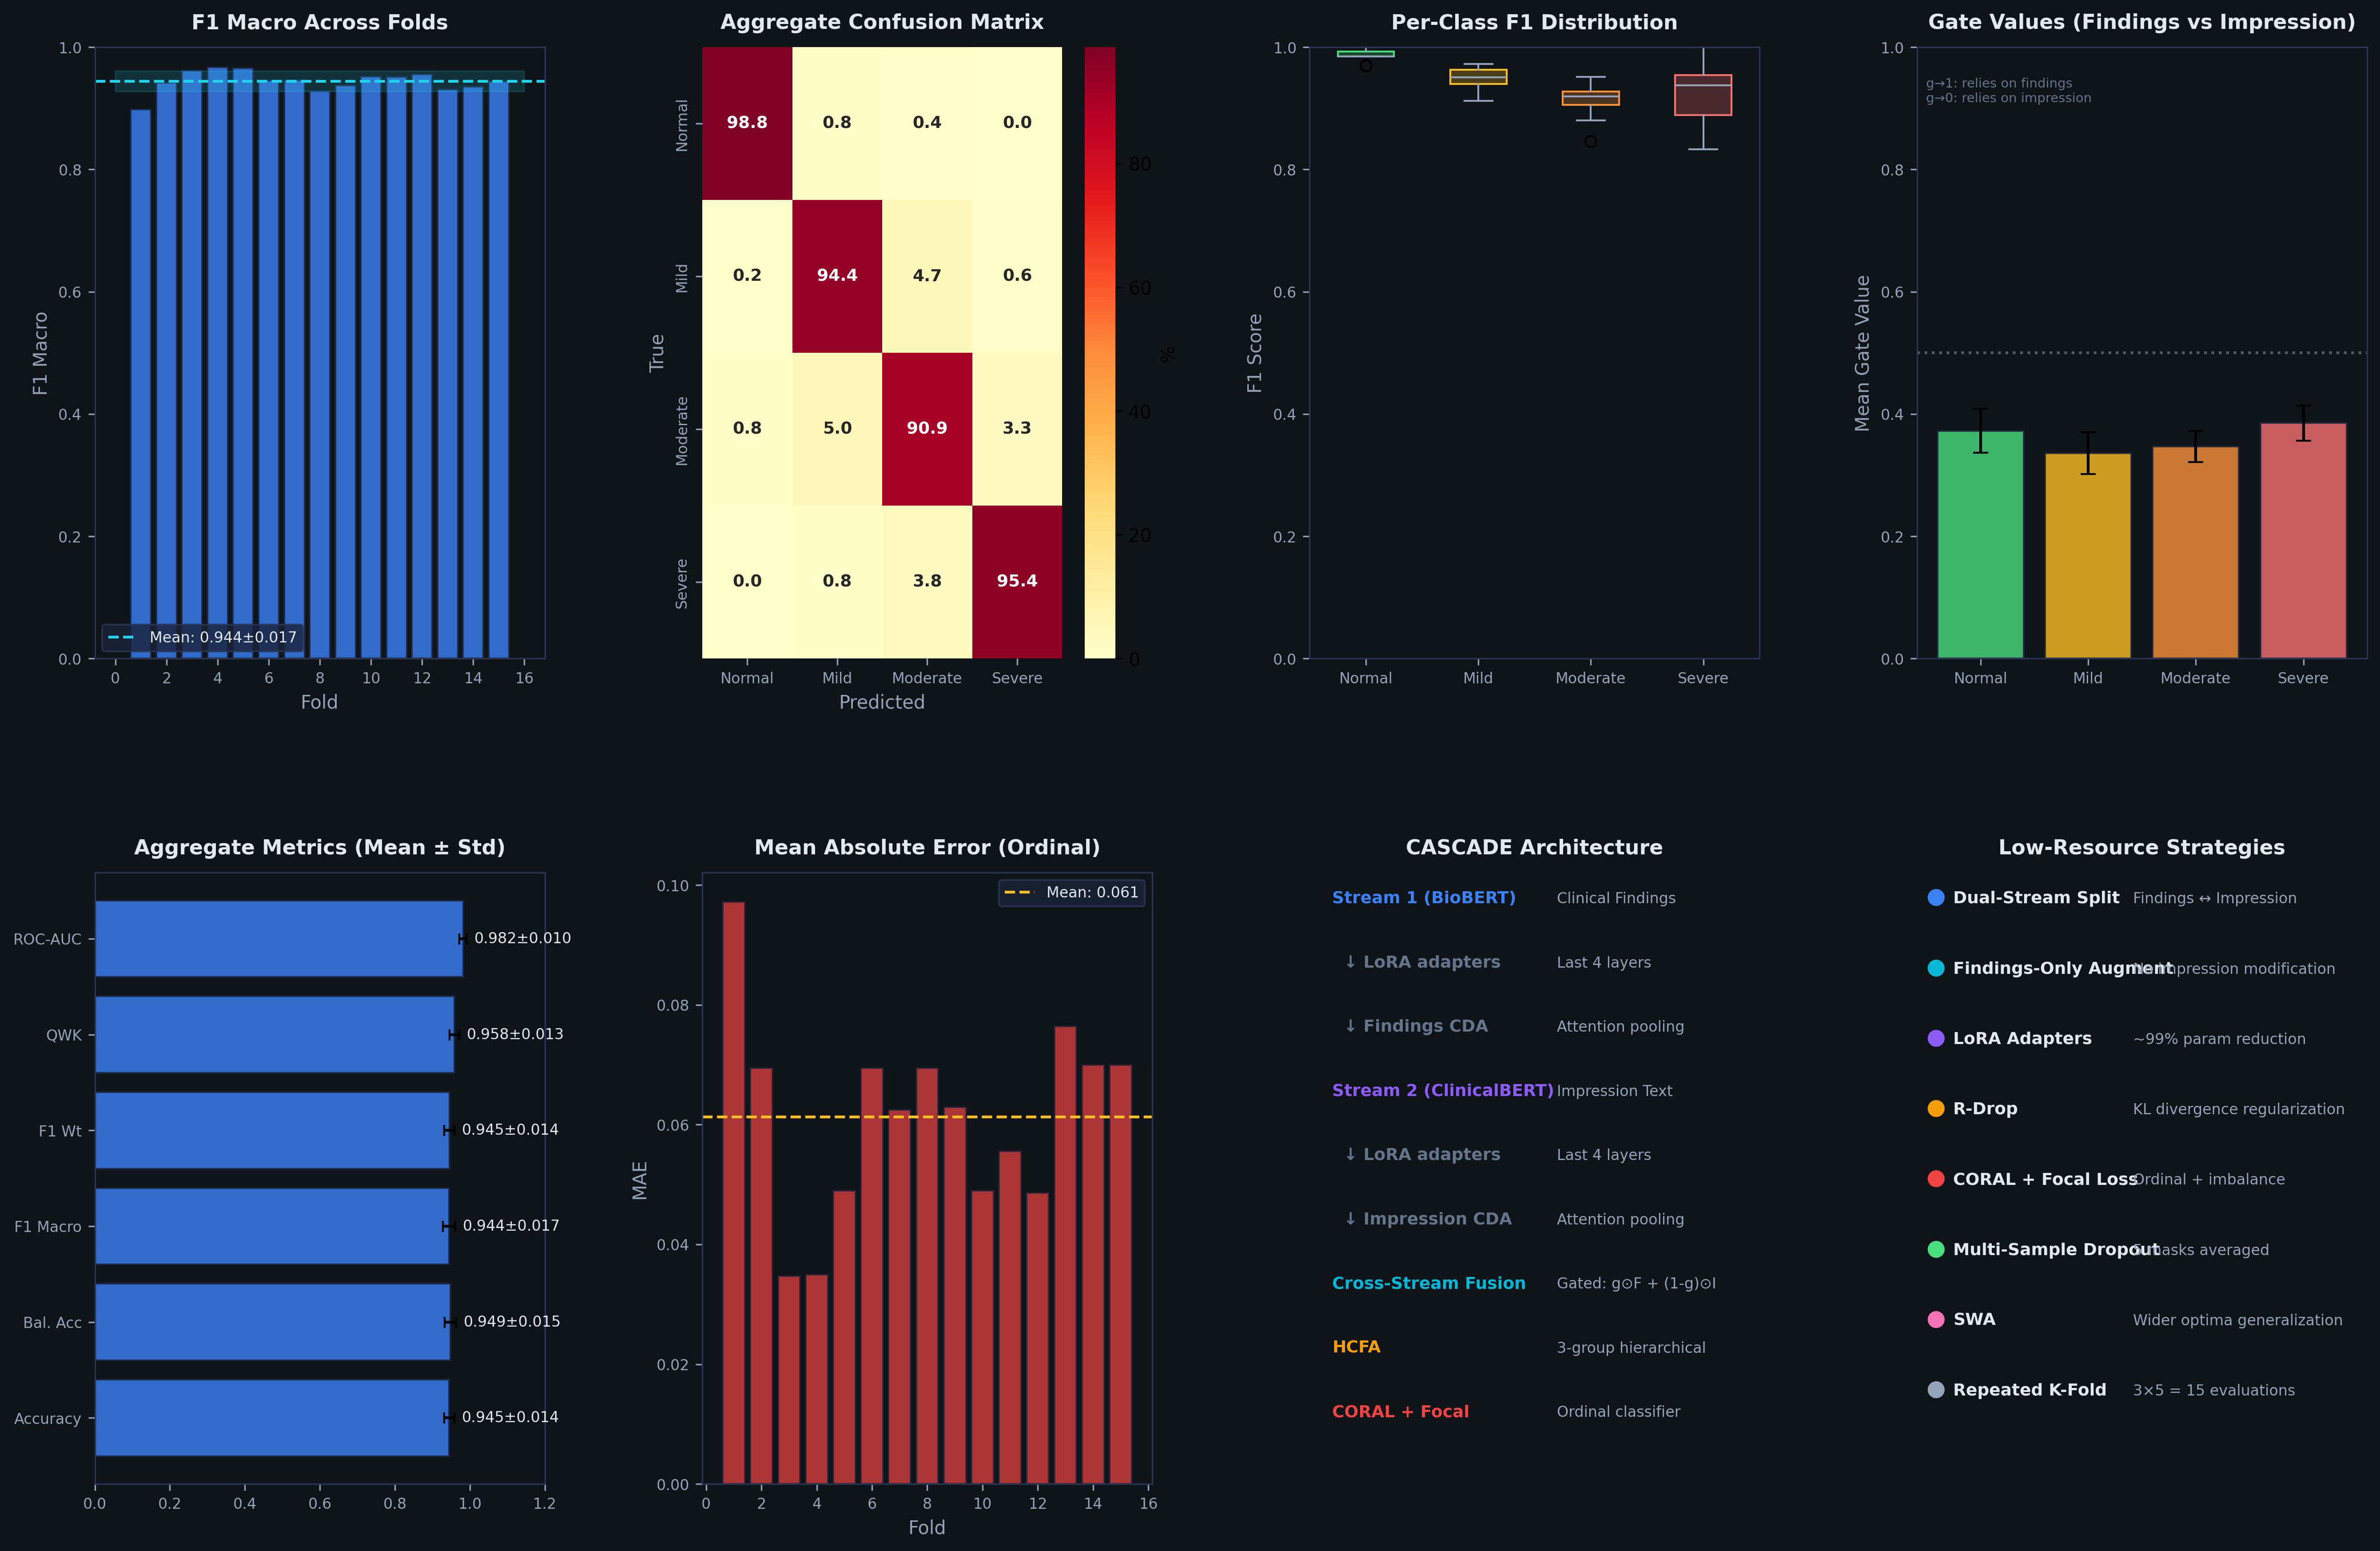

In [20]:
import importlib
import train_cds_fusion_v2
importlib.reload(train_cds_fusion_v2)
from train_cds_fusion_v2 import plot_results, V2Config
import glob
import os
from IPython.display import Image, display

# Re-plot using existing metrics
run_dirs = sorted(glob.glob("outputs_v2/run_*"))
if run_dirs:
    latest = run_dirs[-1]
    try:
        plot_results(all_fold_metrics, config, latest)
        display(Image(os.path.join(latest, "cds_fusion_v2_results.png")))
    except NameError:
        print("Variables not in memory. Please run training or load metrics first.")

In [8]:
import train_cds_fusion_v2
importlib.reload(train_cds_fusion_v2)
print("✅ Training pipeline loaded")

✅ Training pipeline loaded


## 5. Sanity Check — Single Forward Pass

In [9]:
import torch
from transformers import AutoTokenizer
from cds_fusion_v2_model import CDSFusionV2, DualStreamEchoDataset, prepare_data

device = "cuda" if torch.cuda.is_available() else "cpu"
bio_tok = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
clin_tok = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

model = CDSFusionV2(encoder_mode="unfreeze", num_unfreeze_layers=4).to(device)
texts, labels, _ = prepare_data("Final_data.csv")
ds = DualStreamEchoDataset(texts[:4], labels[:4], bio_tok, clin_tok, linearize=True)

# Check what BERT sees now
print(f"Linearized findings sample:")
print(f"  {ds.findings_texts[0][:200]}...")
print()

batch = {k: v.unsqueeze(0).to(device) if k != 'label' else v for k, v in ds[0].items()}
model.eval()
with torch.no_grad():
    out = model(batch['bio_input_ids'], batch['bio_attention_mask'],
                batch['clin_input_ids'], batch['clin_attention_mask'])

print(f"✅ Forward pass OK!")
print(f"  Probs: {out['probs'].cpu().numpy().round(3)}")
print(f"  Predicted: {['Normal','Mild','Moderate','Severe'][out['probs'].argmax().item()]}")
print(f"  Ordinal score: {out['ordinal_score'].item():.3f} (0=Normal, 3=Severe)")
print(f"  Gate: {out['gate_values'].mean().item():.3f}")
print(f"  All 4 classes have probability: {(out['probs'] > 0.01).all().item()}")

del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



CDS-Fusion-V2.1 Model Summary (FIXED)
Encoder mode:         unfreeze
Stream 1: BioBERT  → Clinical Findings (augmentable)
Stream 2: ClinicalBERT → Impression (not augmented)
Total parameters:      225,196,615
Trainable parameters:   65,279,047 (29.0%)
Frozen parameters:     159,917,568 (71.0%)
BioBERT trainable:      28,351,488
ClinicalBERT train:     28,351,488

Loaded 718 records from Final_data.csv
Label distribution: {2: 205, 0: 165, 1: 269, 3: 79}
Linearized findings sample:
  Patient age 55 years. Sex male. LV internal dimension in diastole 56 millimeters. Left atrium 39 millimeters. LV internal dimension in systole 44 millimeters. Aortic root 28 millimeters. Ejection frac...



model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

✅ Forward pass OK!
  Probs: [[0.244 0.238 0.261 0.258]]
  Predicted: Moderate
  Ordinal score: -0.131 (0=Normal, 3=Severe)
  Gate: 0.499
  All 4 classes have probability: True


## 6. Train CDS-Fusion-V2.2| Setting | Quick Test | Full Run ||---------|-----------|----------|| `repeats` | 1 | 3 || `folds` | 3 | 5 || `epochs` | 15 | 40 || ~Time (A100) | ~10 min | ~1.5 hours |

In [10]:
importlib.reload(train_cds_fusion_v2)
from train_cds_fusion_v2 import V2Config, main as train_main, set_seed

config = V2Config()
config.data_path = "/content/Final_data.csv"

# ===== ENCODER =====
config.encoder_mode = "unfreeze"
config.num_unfreeze_layers = 4

# ===== SPEED (adjust these) =====
config.num_repeats = 3             # Quick: 1, Full: 3
config.num_folds = 5               # Quick: 3, Full: 5
config.epochs = 40                 # Quick: 15, Full: 40

# ===== A100 SETTINGS =====
config.batch_size = 16
config.gradient_accumulation_steps = 2  # Effective batch = 32

# ===== LEARNING RATE (v2.2 fix) =====
config.learning_rate = 3e-4        # Head LR
config.encoder_lr_factor = 0.3     # Encoder gets 9e-5 (was 3e-5, too low)

# ===== LOSS (v2.2 fix) =====
config.focal_weight = 0.6
config.ordinal_weight = 0.2
config.rdrop_weight = 0.2

print(f"Training: {config.num_repeats}x{config.num_folds} = {config.num_repeats*config.num_folds} folds")
print(f"Encoder LR: {config.learning_rate * config.encoder_lr_factor:.1e}")
print(f"Head LR: {config.learning_rate:.1e}")
print(f"Device: {config.device}, AMP: {config.use_amp}")

Training: 3x5 = 15 folds
Encoder LR: 9.0e-05
Head LR: 3.0e-04
Device: cuda, AMP: True


In [11]:
# ▶️ RUN TRAINING
set_seed(config.seed)
summary, all_fold_metrics = train_main(config)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)
for metric, values in summary.items():
    if isinstance(values, dict) and 'mean' in values:
        print(f"  {metric}: {values['mean']:.4f} ± {values['std']:.4f}")

Loaded 718 records from /content/Final_data.csv
Label distribution: {2: 205, 0: 165, 1: 269, 3: 79}

Augmentation summary:
  Original: {2: 164, 0: 132, 1: 215, 3: 63}
  After Stage 1 (uniform): {2: 328, 0: 264, 1: 430, 3: 126}
  After Stage 2 (balanced): {2: 430, 0: 430, 1: 430, 3: 430}
  Total: 574 → 1720


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



CDS-Fusion-V2.1 Model Summary (FIXED)
Encoder mode:         unfreeze
Stream 1: BioBERT  → Clinical Findings (augmentable)
Stream 2: ClinicalBERT → Impression (not augmented)
Total parameters:      225,196,615
Trainable parameters:   65,279,047 (29.0%)
Frozen parameters:     159,917,568 (71.0%)
BioBERT trainable:      28,351,488
ClinicalBERT train:     28,351,488


TRAINING COMPLETE!
  accuracy: 0.9452 ± 0.0139
  balanced_accuracy: 0.9486 ± 0.0153
  f1_macro: 0.9442 ± 0.0168
  f1_weighted: 0.9453 ± 0.0139
  qwk: 0.9584 ± 0.0130
  mae: 0.0613 ± 0.0159
  roc_auc: 0.9821 ± 0.0098


## 7. View Results

Run: outputs_v2/run_20260304_024550


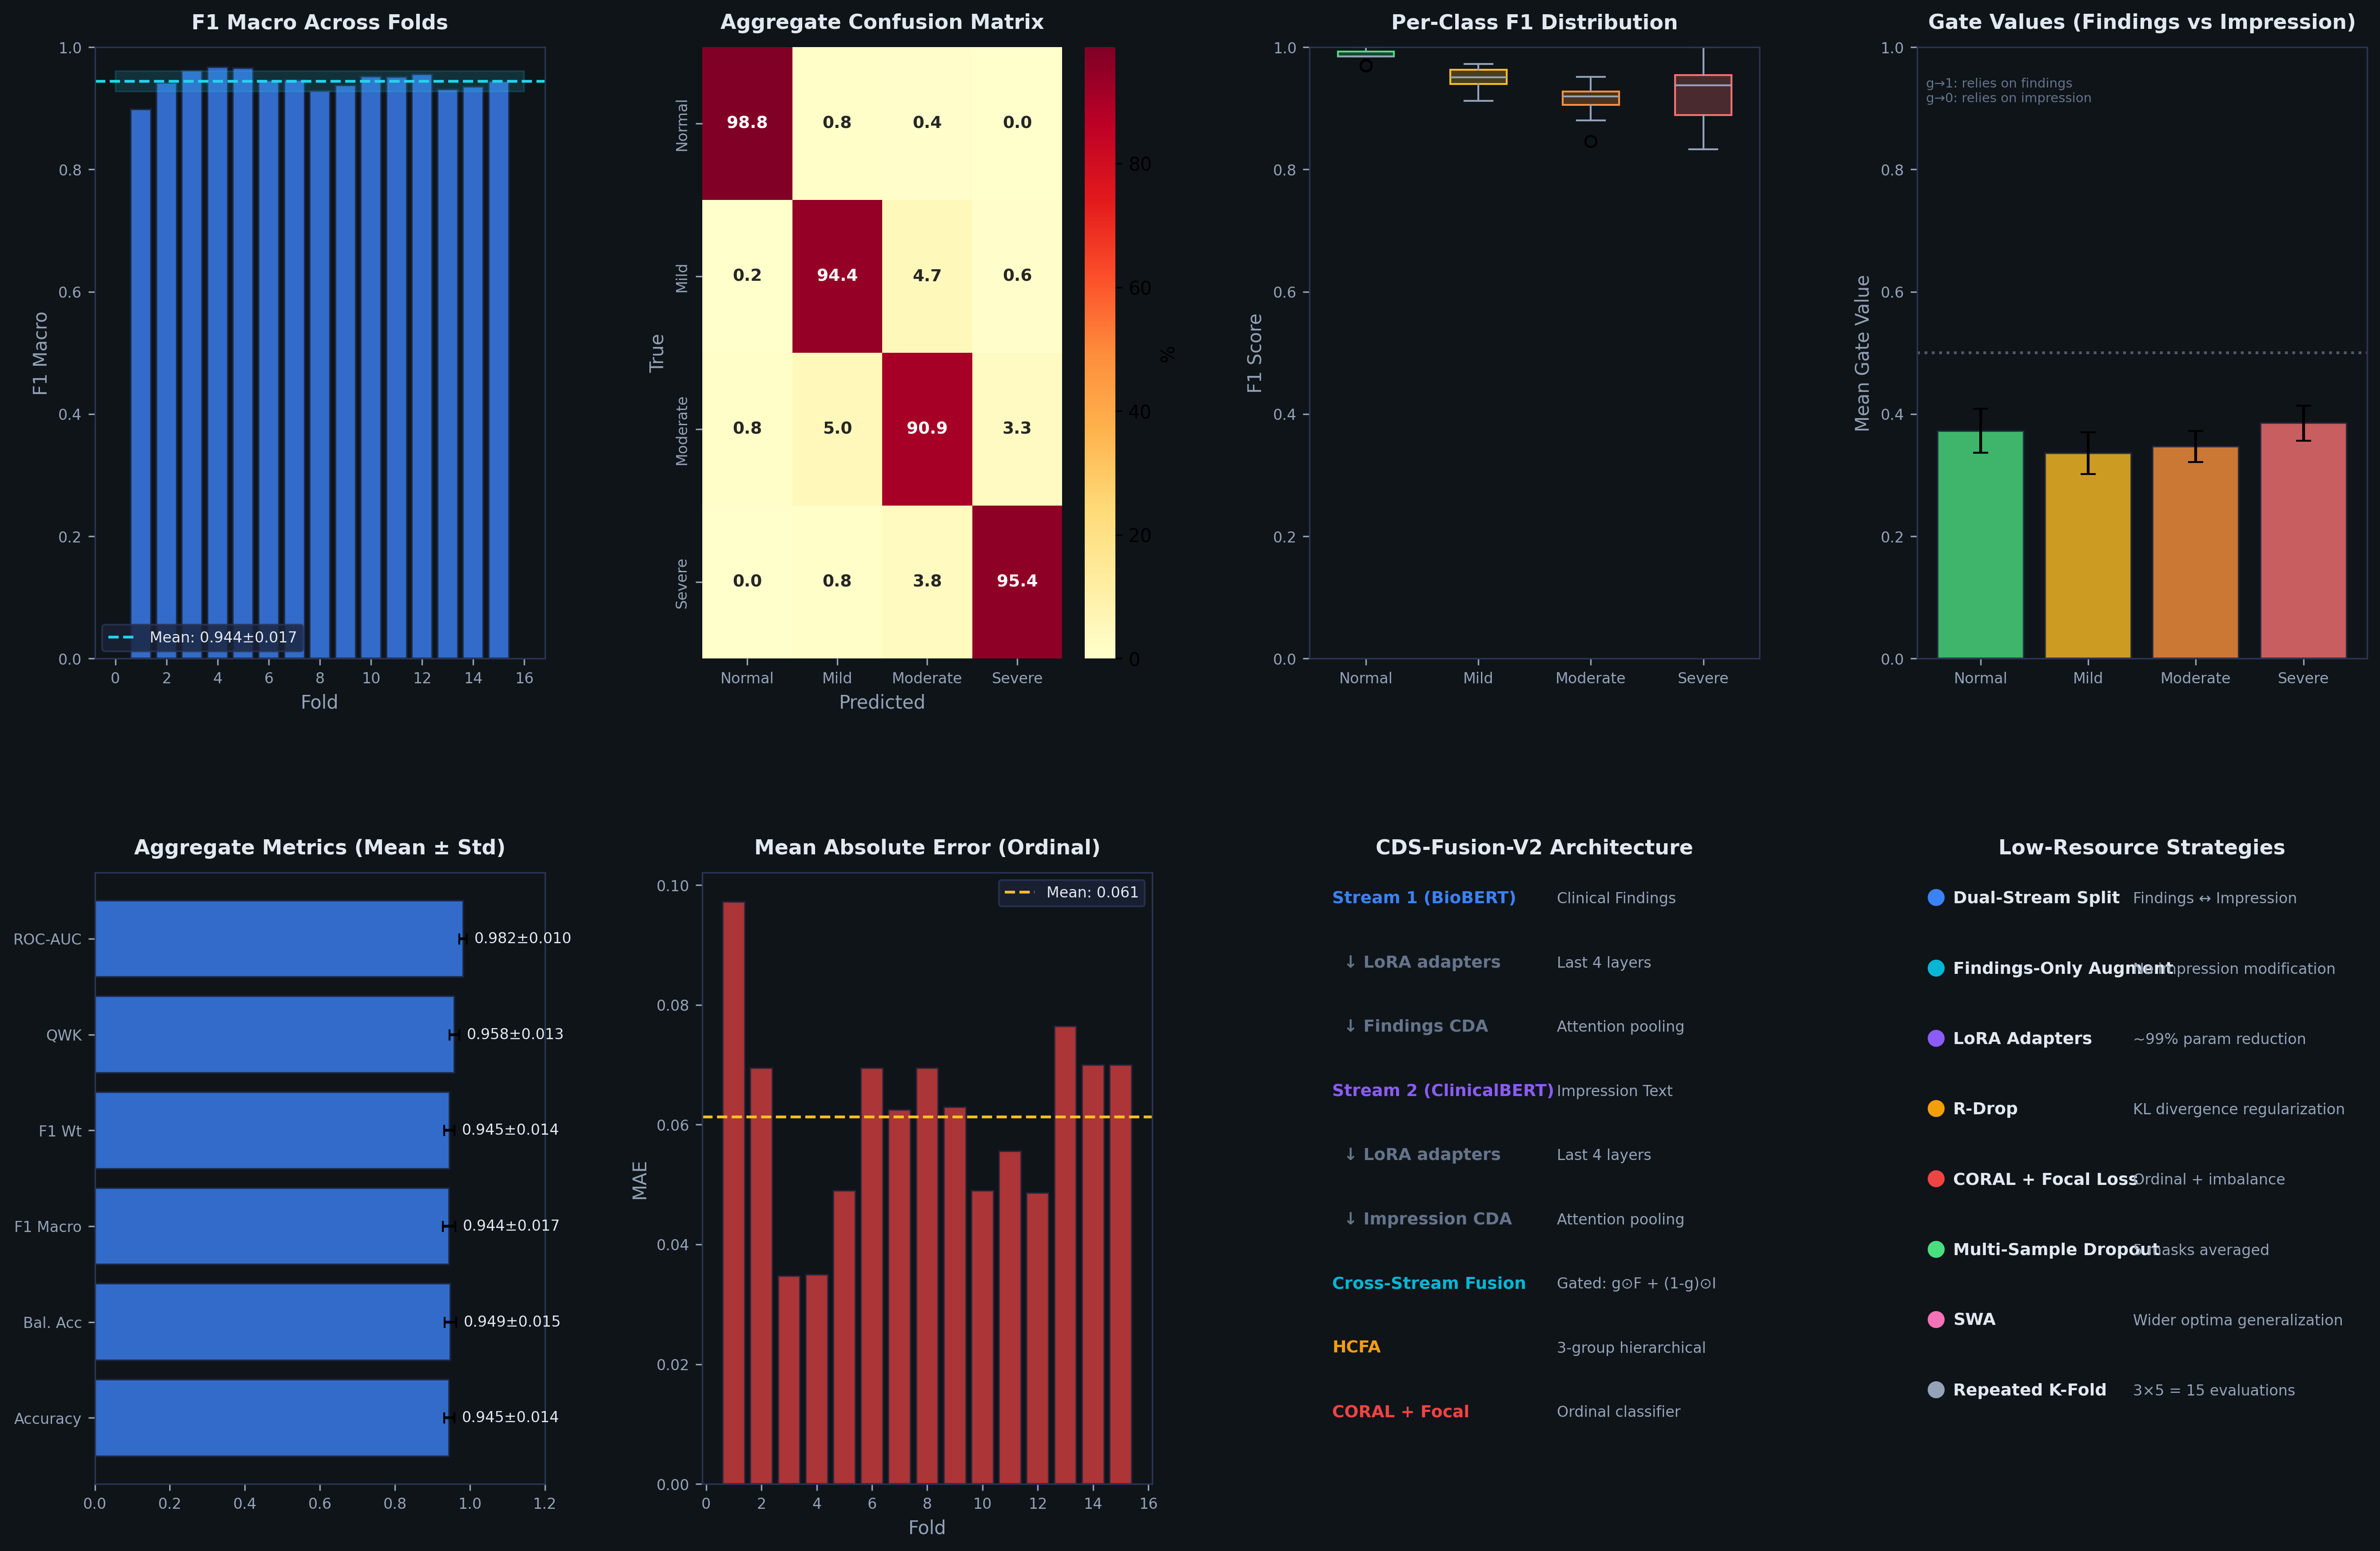


Metrics:
  accuracy: 0.9452 ± 0.0139
  balanced_accuracy: 0.9486 ± 0.0153
  f1_macro: 0.9442 ± 0.0168
  f1_weighted: 0.9453 ± 0.0139
  qwk: 0.9584 ± 0.0130
  mae: 0.0613 ± 0.0159
  roc_auc: 0.9821 ± 0.0098


In [12]:
import glob, json
from IPython.display import Image, display

run_dirs = sorted(glob.glob("outputs_v2/run_*"))
if run_dirs:
    latest = run_dirs[-1]
    print(f"Run: {latest}")
    plot = os.path.join(latest, "CASCADE_results.png")
    if os.path.exists(plot):
        display(Image(plot, width=900))
    with open(os.path.join(latest, "summary.json")) as f:
        s = json.load(f)
    print("\nMetrics:")
    for k, v in s.items():
        if isinstance(v, dict) and 'mean' in v:
            print(f"  {k}: {v['mean']:.4f} ± {v['std']:.4f}")

## 8. Baseline Models

In [13]:
%%writefile baseline_models.py
"""
Baseline Models for CDS-Fusion-V2 Comparison (Tier 1)
======================================================

These baselines answer the reviewer question:
  "Why do you need a dual-stream transformer? Couldn't simpler models work?"

Baselines:
  1A. TF-IDF + Gradient Boosting (text)
  1B. TF-IDF + XGBoost (text)
  1C. TF-IDF + Random Forest (text)
  1D. TF-IDF + Logistic Regression (text)
  2A. Structured features + XGBoost (tabular)
  2B. Structured features + Random Forest (tabular)

Each baseline uses Repeated Stratified K-Fold (3×5) with same seed
as CDS-Fusion-V2 for fair comparison.

Usage:
  python baseline_models.py --data_path Final_data.csv
  python baseline_models.py --data_path Final_data.csv --features_path extracted_medical_reports_only_features.xlsx

Author: [Your Name]
"""

import os
import re
import json
import argparse
import logging
import warnings
from datetime import datetime
from collections import Counter
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    cohen_kappa_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score,
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("⚠️  XGBoost not installed. Install with: pip install xgboost")

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

LABEL_MAP = {"Normal": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
SEED = 42


# ============================================================================
# DATA LOADING
# ============================================================================

def load_text_data(csv_path: str) -> Tuple[List[str], List[str], List[int]]:
    """
    Load Final_data.csv and create three text variants:
    - full_text: complete Medical_Report (with Impression)
    - findings_text: everything BEFORE Impression
    - impression_text: only the Impression
    """
    df = pd.read_csv(csv_path)
    labels = [LABEL_MAP[l] for l in df['label'].tolist()]

    full_texts = []
    findings_texts = []

    for text in df['Medical_Report']:
        text = str(text)
        text_clean = re.sub(r"\bnan\b", "not measured", text, flags=re.IGNORECASE)
        full_texts.append(text_clean)

        parts = text_clean.rsplit('Impression:', 1)
        findings_texts.append(parts[0].strip().rstrip(',').strip())

    return full_texts, findings_texts, labels


def load_structured_features(xlsx_path: str) -> Tuple[np.ndarray, List[int]]:
    """
    Load structured features from xlsx.
    Handles mixed types: extracts numeric values from measurement strings,
    one-hot encodes categorical fields, drops constant/empty columns.
    """
    df = pd.read_excel(xlsx_path)

    labels = [LABEL_MAP[l] for l in df['label'].tolist()]

    # Separate feature columns
    drop_cols = ['Cardiac_Class', 'label', 'Impression']
    feature_cols = [c for c in df.columns if c not in drop_cols]

    # Process each column
    processed = {}
    for col in feature_cols:
        series = df[col].astype(str).str.strip()

        # Try numeric extraction (e.g., "56 mm" → 56, "41%" → 41)
        numeric = series.str.extract(r'(\d+\.?\d*)')[0].astype(float)

        if numeric.notna().sum() > len(df) * 0.3:
            # Enough numeric values — use as numeric feature
            processed[col] = numeric.fillna(numeric.median())
        else:
            # Categorical — check unique values
            unique = series.replace(['nan', 'N/A', 'not measured', ''], 'missing').unique()
            if len(unique) <= 1:
                continue  # Constant column — skip
            if len(unique) <= 10:
                # One-hot encode
                dummies = pd.get_dummies(
                    series.replace(['nan', 'N/A', 'not measured', ''], 'missing'),
                    prefix=col
                )
                for dummy_col in dummies.columns:
                    processed[dummy_col] = dummies[dummy_col].values.astype(float)
            else:
                # Too many categories — skip (e.g., LV_Wall_Motion free text)
                continue

    features_df = pd.DataFrame(processed)
    logger.info(f"Structured features: {features_df.shape[1]} features from {len(feature_cols)} columns")

    return features_df.values, labels


# ============================================================================
# EVALUATION
# ============================================================================

def evaluate_predictions(y_true, y_pred, y_probs=None) -> Dict:
    """Compute all metrics matching CDS-Fusion-V2 evaluation."""
    target_names = [INV_LABEL_MAP[i] for i in range(4)]

    roc_auc = 0.0
    if y_probs is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            pass

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": float(np.mean(np.abs(np.array(y_pred) - np.array(y_true)))),
        "roc_auc": roc_auc,
        "classification_report": classification_report(
            y_true, y_pred, target_names=target_names,
            digits=4, output_dict=True, zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


# ============================================================================
# BASELINE RUNNERS
# ============================================================================

def run_tfidf_baseline(
    texts: List[str],
    labels: List[int],
    model_name: str,
    model_class,
    model_params: dict,
    n_splits: int = 5,
    n_repeats: int = 3,
) -> Dict:
    """Run TF-IDF + classifier baseline with Repeated Stratified K-Fold."""

    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=SEED)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(rskf.split(texts, labels), 1):
        train_texts = [texts[i] for i in train_idx]
        val_texts = [texts[i] for i in val_idx]
        train_labels = np.array([labels[i] for i in train_idx])
        val_labels = np.array([labels[i] for i in val_idx])

        # TF-IDF
        tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                sublinear_tf=True, min_df=2)
        X_train = tfidf.fit_transform(train_texts)
        X_val = tfidf.transform(val_texts)

        # Train
        clf = model_class(**model_params)
        clf.fit(X_train, train_labels)

        # Predict
        y_pred = clf.predict(X_val)
        y_probs = None
        if hasattr(clf, 'predict_proba'):
            y_probs = clf.predict_proba(X_val)

        metrics = evaluate_predictions(val_labels, y_pred, y_probs)
        fold_metrics.append(metrics)

    return aggregate_results(model_name, fold_metrics)


def run_structured_baseline(
    features: np.ndarray,
    labels: List[int],
    model_name: str,
    model_class,
    model_params: dict,
    n_splits: int = 5,
    n_repeats: int = 3,
) -> Dict:
    """Run structured features + classifier baseline."""

    labels_arr = np.array(labels)
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=SEED)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(rskf.split(features, labels_arr), 1):
        X_train, X_val = features[train_idx], features[val_idx]
        y_train, y_val = labels_arr[train_idx], labels_arr[val_idx]

        # Scale
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # Train
        clf = model_class(**model_params)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_val)
        y_probs = clf.predict_proba(X_val) if hasattr(clf, 'predict_proba') else None

        metrics = evaluate_predictions(y_val, y_pred, y_probs)
        fold_metrics.append(metrics)

    return aggregate_results(model_name, fold_metrics)


# ============================================================================
# AGGREGATION
# ============================================================================

def aggregate_results(model_name: str, fold_metrics: List[Dict]) -> Dict:
    """Aggregate fold metrics into summary with CI."""
    metric_keys = ["accuracy", "balanced_accuracy", "f1_macro",
                   "f1_weighted", "qwk", "mae", "roc_auc"]

    summary = {"model": model_name, "n_folds": len(fold_metrics)}

    for key in metric_keys:
        values = [m[key] for m in fold_metrics]
        mean_val = np.mean(values)
        std_val = np.std(values)
        ci_95 = 1.96 * std_val / np.sqrt(len(values))
        summary[key] = {
            "mean": round(float(mean_val), 4),
            "std": round(float(std_val), 4),
            "ci_95": round(float(ci_95), 4),
        }

    # Per-class F1
    per_class = {}
    for label_name in LABEL_MAP.keys():
        f1s = [m["classification_report"].get(label_name, {}).get("f1-score", 0)
               for m in fold_metrics]
        per_class[label_name] = {
            "mean": round(float(np.mean(f1s)), 4),
            "std": round(float(np.std(f1s)), 4),
        }
    summary["per_class_f1"] = per_class

    # Aggregate confusion matrix
    summary["confusion_matrix"] = sum(m["confusion_matrix"] for m in fold_metrics).tolist()

    return summary


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_baseline_comparison(all_results: List[Dict], output_dir: str):
    """Compare all baselines side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor('#0f1419')

    model_names = [r["model"] for r in all_results]
    colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

    for ax in axes:
        ax.set_facecolor('#0f1419')
        ax.tick_params(colors='#94a3b8', labelsize=8)
        for spine in ax.spines.values():
            spine.set_color('#2a3555')

    # 1. F1 Macro comparison
    ax = axes[0]
    means = [r["f1_macro"]["mean"] for r in all_results]
    stds = [r["f1_macro"]["std"] for r in all_results]
    bars = ax.barh(model_names, means, xerr=stds, color=colors, alpha=0.8,
                   edgecolor='#1a2238', capsize=3)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2,
                f'{mean:.3f}', va='center', color='#e2e8f0', fontsize=8)
    ax.set_title('F1 Macro', color='#e2e8f0', fontweight='bold')
    ax.set_xlim(0, 1.1)

    # 2. QWK comparison
    ax = axes[1]
    means = [r["qwk"]["mean"] for r in all_results]
    stds = [r["qwk"]["std"] for r in all_results]
    bars = ax.barh(model_names, means, xerr=stds, color=colors, alpha=0.8,
                   edgecolor='#1a2238', capsize=3)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2,
                f'{mean:.3f}', va='center', color='#e2e8f0', fontsize=8)
    ax.set_title('QWK (Ordinal)', color='#e2e8f0', fontweight='bold')
    ax.set_xlim(0, 1.1)

    # 3. Per-class F1 for Severe (hardest class)
    ax = axes[2]
    severe_means = [r["per_class_f1"]["Severe"]["mean"] for r in all_results]
    severe_stds = [r["per_class_f1"]["Severe"]["std"] for r in all_results]
    bars = ax.barh(model_names, severe_means, xerr=severe_stds, color='#f87171',
                   alpha=0.8, edgecolor='#1a2238', capsize=3)
    for bar, mean, std in zip(bars, severe_means, severe_stds):
        ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2,
                f'{mean:.3f}', va='center', color='#e2e8f0', fontsize=8)
    ax.set_title('F1 Severe (Minority)', color='#e2e8f0', fontweight='bold')
    ax.set_xlim(0, 1.1)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "baseline_comparison.png"), dpi=300,
                bbox_inches='tight', facecolor='#0f1419')
    plt.close()


# ============================================================================
# MAIN
# ============================================================================

def main():
    parser = argparse.ArgumentParser(description="Run baseline models")
    parser.add_argument("--data_path", type=str, default="Final_data.csv")
    parser.add_argument("--features_path", type=str, default=None,
                        help="Path to structured features xlsx (optional)")
    parser.add_argument("--folds", type=int, default=5)
    parser.add_argument("--repeats", type=int, default=3)
    parser.add_argument("--output_dir", type=str, default="outputs_baselines")
    args = parser.parse_args()

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = os.path.join(args.output_dir, f"run_{timestamp}")
    os.makedirs(output_dir, exist_ok=True)

    logger.info("=" * 70)
    logger.info("BASELINE MODELS — CDS-Fusion-V2 Comparison")
    logger.info("=" * 70)

    # Load text data
    full_texts, findings_texts, labels = load_text_data(args.data_path)
    logger.info(f"Loaded {len(full_texts)} records, distribution: {dict(Counter(labels))}")

    all_results = []

    # ---- TEXT BASELINES ----

    # 1A. TF-IDF + GBM (full text)
    logger.info("\n--- TF-IDF + GBM (full text) ---")
    result = run_tfidf_baseline(
        full_texts, labels, "TF-IDF+GBM (full)",
        GradientBoostingClassifier,
        {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1, "random_state": SEED},
        args.folds, args.repeats,
    )
    all_results.append(result)
    logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

    # 1B. TF-IDF + GBM (findings only — matches Stream 1 input)
    logger.info("\n--- TF-IDF + GBM (findings only) ---")
    result = run_tfidf_baseline(
        findings_texts, labels, "TF-IDF+GBM (findings)",
        GradientBoostingClassifier,
        {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1, "random_state": SEED},
        args.folds, args.repeats,
    )
    all_results.append(result)
    logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

    # 1C. TF-IDF + Random Forest (full text)
    logger.info("\n--- TF-IDF + RF (full text) ---")
    result = run_tfidf_baseline(
        full_texts, labels, "TF-IDF+RF (full)",
        RandomForestClassifier,
        {"n_estimators": 300, "max_depth": 15, "class_weight": "balanced", "random_state": SEED},
        args.folds, args.repeats,
    )
    all_results.append(result)
    logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

    # 1D. TF-IDF + Logistic Regression (full text)
    logger.info("\n--- TF-IDF + LogReg (full text) ---")
    result = run_tfidf_baseline(
        full_texts, labels, "TF-IDF+LogReg (full)",
        LogisticRegression,
        {"C": 1.0, "max_iter": 1000, "class_weight": "balanced", "random_state": SEED},
        args.folds, args.repeats,
    )
    all_results.append(result)
    logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

    # 1E. TF-IDF + XGBoost (if available)
    if HAS_XGBOOST:
        logger.info("\n--- TF-IDF + XGBoost (full text) ---")
        result = run_tfidf_baseline(
            full_texts, labels, "TF-IDF+XGB (full)",
            XGBClassifier,
            {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,
             "use_label_encoder": False, "eval_metric": "mlogloss", "random_state": SEED},
            args.folds, args.repeats,
        )
        all_results.append(result)
        logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

    # ---- STRUCTURED FEATURE BASELINES ----
    if args.features_path and os.path.exists(args.features_path):
        features, struct_labels = load_structured_features(args.features_path)

        if HAS_XGBOOST:
            logger.info("\n--- Structured + XGBoost ---")
            result = run_structured_baseline(
                features, struct_labels, "Structured+XGB",
                XGBClassifier,
                {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,
                 "use_label_encoder": False, "eval_metric": "mlogloss", "random_state": SEED},
                args.folds, args.repeats,
            )
            all_results.append(result)
            logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

        logger.info("\n--- Structured + RF ---")
        result = run_structured_baseline(
            features, struct_labels, "Structured+RF",
            RandomForestClassifier,
            {"n_estimators": 300, "max_depth": 15, "class_weight": "balanced", "random_state": SEED},
            args.folds, args.repeats,
        )
        all_results.append(result)
        logger.info(f"  F1 Macro: {result['f1_macro']['mean']:.4f} ± {result['f1_macro']['std']:.4f}")

    # ---- SUMMARY TABLE ----
    logger.info(f"\n{'='*70}")
    logger.info("BASELINE RESULTS SUMMARY")
    logger.info(f"{'='*70}")
    logger.info(f"{'Model':<30s} {'F1 Macro':>12s} {'QWK':>12s} {'Bal.Acc':>12s} {'Severe F1':>12s}")
    logger.info("-" * 78)
    for r in all_results:
        logger.info(
            f"{r['model']:<30s} "
            f"{r['f1_macro']['mean']:.4f}±{r['f1_macro']['std']:.4f} "
            f"{r['qwk']['mean']:.4f}±{r['qwk']['std']:.4f} "
            f"{r['balanced_accuracy']['mean']:.4f}±{r['balanced_accuracy']['std']:.4f} "
            f"{r['per_class_f1']['Severe']['mean']:.4f}±{r['per_class_f1']['Severe']['std']:.4f}"
        )

    # Save
    with open(os.path.join(output_dir, "baseline_results.json"), "w") as f:
        json.dump(all_results, f, indent=2, default=str)

    plot_baseline_comparison(all_results, output_dir)

    logger.info(f"\nResults saved to: {output_dir}")
    return all_results


if __name__ == "__main__":
    main()


Writing baseline_models.py


In [14]:
import sys, baseline_models
importlib.reload(baseline_models)
sys.argv = ['baseline_models.py', '--data_path', 'Final_data.csv', '--folds', '5', '--repeats', '3']
baseline_results = baseline_models.main()

## 10. Download Results

In [17]:
import shutil
from google.colab import files
for d, z in [("outputs_v2", "v2_results"), ("outputs_baselines", "baseline_results")]:
    if os.path.exists(d):
        shutil.make_archive(z, 'zip', d)
        files.download(f"{z}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
!ls -lh *.zip

-rw-r--r-- 1 root root 95K Mar  4 04:52 baseline_results.zip
-rw-r--r-- 1 root root 12G Mar  4 04:52 v2_results.zip
